# SMS Spam Detection - Comprehensive Study
## Classical ML vs Ensemble Learning vs Deep Learning

In [33]:
# IMPORTS AND SETUP 
# =============================================================================

# 1. CORE DATA & VISUALIZATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
import os
# Hardware monitoring
import psutil
import time
from datetime import timedelta, datetime
from matplotlib.patches import Patch

# 2. NLP & TEXT PROCESSING
import re, string, emoji, unicodedata
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from bs4 import BeautifulSoup

# 3. SKLEARN - CLASSICAL & ENSEMBLE MODELS
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    average_precision_score, matthews_corrcoef, cohen_kappa_score,
    roc_curve, auc, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 4. DEEP LEARNING (KERAS – STABLE)
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import (
    LSTM, GRU, Dense, Embedding, Dropout,
    Conv1D, GlobalMaxPooling1D, Bidirectional
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


# 5. TRANSFORMERS (HuggingFace – TF Models)
from transformers import (
    DistilBertTokenizer,
    TFDistilBertForSequenceClassification,
    logging as transformers_logging
)

# 6. Energy & Carbon tracking
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
    print("✅ CodeCarbon available for energy tracking")
except ImportError:
    CODECARBON_AVAILABLE = False
    print("⚠️ CodeCarbon not installed")

# 7. CONFIGURATION
import warnings
warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()

print("✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)")

✅ CodeCarbon available for energy tracking
✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)


In [34]:
# ====================================================================================
# GLOBAL MODULAR UTILITIES 
# ====================================================================================

# --- Storage: JSON + CSV Files ---
from pathlib import Path
OUTPUT_DIR = Path('Json_Csv_results')
OUTPUT_DIR.mkdir(exist_ok=True)
RESULTS_JSON = OUTPUT_DIR / 'model_results.json'
RESULTS_CSV = OUTPUT_DIR / 'model_results.csv'

# ====================================================================================
# CARBON EMISSION FACTOR (CEF) — IEA 2024, Turkey National Grid
# ====================================================================================
# Source: IEA Emissions Factors 2024
# Turkey grid mix: ~33% coal, ~21% gas, ~17% hydro (fossil-heavy)
# CEF dynamically confirmed by CodeCarbon v3.2.2 during experiments (measured: 0.465)
CEF_KG_PER_KWH   = 0.465   # kg CO2/kWh  — used in all energy/CO2 calculations
CEF_GCO2_PER_KWH = 465     # gCO2/kWh    — used in paper tables and reporting

# ====================================================================================
# TIME UTILITIES
# ====================================================================================
def format_time(seconds):
    if seconds < 1:
        return f"{seconds * 1000:.3f} ms"
    return f"{seconds:.4f} sec"

class TimeTracker:
    def __init__(self):
        self._starts = {}

    def start(self, key):
        self._starts[key] = time.perf_counter()

    def stop(self, key):
        return time.perf_counter() - self._starts[key]

timer = TimeTracker()

# ====================================================================================
# THRESHOLD OPTIMIZATION (simple — for backward compatibility)
# ====================================================================================
def optimize_threshold_cv(model, X, y, cv=5):
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = [
        matthews_corrcoef(y, (cv_pred_proba >= t).astype(int))
        for t in thresholds
    ]

    best_idx = np.argmax(mcc_scores)
    return thresholds[best_idx], mcc_scores[best_idx]

def measure_inference_latency(model, X):
    if hasattr(X, 'toarray'):
        X = X.toarray()
    model.predict_proba(X[:5])
    start = time.perf_counter()
    for i in range(X.shape[0]):
        model.predict_proba(X[i:i+1])
    end = time.perf_counter()
    total = end - start
    latency_ms = (total / X.shape[0]) * 1000
    return total, latency_ms

# ====================================================================================
# METRICS COMPUTATION
# ====================================================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy":         accuracy_score(y_true, y_pred),
        "Precision":        precision_score(y_true, y_pred),
        "Recall":           recall_score(y_true, y_pred),
        "F1_Score":         f1_score(y_true, y_pred),
        "MCC":              matthews_corrcoef(y_true, y_pred),
        "Kappa":            cohen_kappa_score(y_true, y_pred),
        "Specificity":      tn / (tn + fp) if (tn + fp) > 0 else 0,
        "ROC_AUC":          roc_auc_score(y_true, y_prob),
        "PR_AUC":           average_precision_score(y_true, y_prob),
        "Confusion_Matrix": np.array([[tn, fp], [fn, tp]])
    }

def print_metrics(metrics, threshold):
    print(f"\n✓ Accuracy (Threshold {threshold:.2f}): {metrics['Accuracy']:.4f}")
    print(f"✓ F1-Score:      {metrics['F1_Score']:.4f}")
    print(f"✓ ROC-AUC Score: {metrics['ROC_AUC']:.4f}")
    print(f"✓ PR-AUC Score:  {metrics['PR_AUC']:.4f}")
    print(f"✓ MCC Score:     {metrics['MCC']:.4f}")
    print(f"✓ Cohen's Kappa: {metrics['Kappa']:.4f}")
    print(f"✓ Specificity:   {metrics['Specificity']:.4f}")

def plot_confusion_matrix(cm, model_name, threshold, cmap='Blues'):
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ham', 'Spam']
    ).plot(cmap=cmap, values_format='d', ax=plt.gca())  # ← cmap direkt string
    plt.title(f"{model_name} Confusion Matrix (Threshold {threshold:.2f})", fontsize=11)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# ====================================================================================
# MODEL SIZE
# ====================================================================================
def get_model_size_mb(model):
    tmp = "_tmp_model.pkl"
    joblib.dump(model, tmp)
    size = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return size

# ====================================================================================
# CREATE DL MODEL (LSTM, GRU, CNN)
# ====================================================================================
def create_model(model_type='lstm', max_words=None, max_len=None, tokenizer_obj=None):

    tf.keras.backend.clear_session()
    
    # Use provided parameters or fall back to globals
    _max_words = max_words if max_words is not None else MAX_WORDS
    _max_len = max_len if max_len is not None else MAX_LEN
    _tokenizer = tokenizer_obj if tokenizer_obj is not None else tokenizer
    
    # Calculate actual vocabulary size (capped at max_words)
    vocab_size = min(_max_words, len(_tokenizer.word_index) + 1)
    
    # Initialize layer list with embedding layer
    # Embedding converts word indices to dense vectors
    layers = [Embedding(input_dim=vocab_size, output_dim=128, input_length=_max_len)]
    
    # Add architecture-specific layers
    if model_type == 'lstm':
        # Bidirectional LSTM: captures context from both directions
        # return_sequences=True: output sequence for stacking layers
        layers.extend([
            Bidirectional(LSTM(64, return_sequences=True)),
            Dropout(0.5),  # Prevent overfitting
            Bidirectional(LSTM(32)),
            Dropout(0.5)
        ])
    
    elif model_type == 'gru':
        # Bidirectional GRU: similar to LSTM but computationally lighter
        layers.extend([
            Bidirectional(GRU(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(GRU(32)),
            Dropout(0.5)
        ])
    
    elif model_type == 'cnn':
        # 1D Convolutional layers: extract local features from text
        # kernel_size=5: looks at 5 consecutive words
        layers.extend([
            Conv1D(128, kernel_size=5, activation='relu'),
            Dropout(0.5),
            Conv1D(64, kernel_size=3, activation='relu'),
            GlobalMaxPooling1D(),  # Extract most important features
            Dropout(0.5)
        ])
    
    else:
        # Invalid model type - provide clear error message
        raise ValueError(
            f"Invalid model type: '{model_type}'. "
            f"Must be 'lstm', 'gru', or 'cnn'."
        )
    
    # Add shared dense layers for all architectures
    # These layers learn high-level representations for classification
    layers.extend([
        Dense(32, activation='relu'),  # Hidden layer
        Dropout(0.3),                  # Regularization
        Dense(1, activation='sigmoid')  # Output layer (binary classification)
    ])
    
    # Create sequential model from layer list
    model = Sequential(layers)
    
    # Compile model with optimizer and loss function
    # adam: adaptive learning rate optimizer
    # binary_crossentropy: loss for binary classification
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model
    
# ====================================================================================
# TRACK MODEL TRAINING
# ====================================================================================
def track_model_training(model, X_train, y_train, X_test, model_name="Model", **kwargs):
    import tracemalloc  # ← EKLEME 1
    
    process = psutil.Process(os.getpid())
    ram_baseline = process.memory_info().rss / (1024 * 1024)
    
    # Start memory tracking
    tracemalloc.start()  # ← EKLEME 2
    
    if CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(project_name=f"SMS_Spam_{model_name}", log_level="error")
        tracker.start()
    
    timer.start(f"{model_name}_train_internal")
    model.fit(X_train, y_train, **kwargs)
    training_time = timer.stop(f"{model_name}_train_internal")
    
    # Get peak memory and stop tracking
    current_mem, peak_mem = tracemalloc.get_traced_memory()  # ← EKLEME 3
    tracemalloc.stop()  # ← EKLEME 4
    ram_peak = peak_mem / (1024 * 1024)  # ← DEĞİŞTİRİLDİ (tracemalloc'tan)
    
    training_co2_kg = 0.0
    training_energy_kwh = 0.0
    if CODECARBON_AVAILABLE:
        try:
            training_co2_kg = float(tracker.stop() or 0.0)
            if hasattr(tracker, 'final_emissions_data') and tracker.final_emissions_data:
                training_energy_kwh = float(tracker.final_emissions_data.energy_consumed)
        except Exception as e:
            print(f"⚠️ CodeCarbon training tracking error: {e}")
    
    cpu_percent = psutil.cpu_percent(interval=0.1)
    gpu_used = False
    gpu_memory_mb = None
    try:
        import GPUtil
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_used = True
            gpu_memory_mb = gpus[0].memoryUsed
    except:
        pass
    
    n_train = X_train.shape[0]
    energy_per_1000_train_wh = (training_energy_kwh * 1e6) / n_train if n_train > 0 else 0.0
    
    return {
        "training_co2_kg": training_co2_kg,
        "training_energy_kwh": training_energy_kwh,
        "energy_per_1000_train_wh": energy_per_1000_train_wh,
        "training_time": training_time,
        "CEF_kg_per_kWh": CEF_KG_PER_KWH,
        "CEF_gCO2_per_kWh": CEF_GCO2_PER_KWH,
        "ram_baseline_mb": ram_baseline,
        "ram_peak_mb": ram_peak,
        "cpu_utilization": cpu_percent,
        "gpu_used": gpu_used,
        "gpu_memory_mb": gpu_memory_mb,
    }

# ====================================================================================
# MEASURE INFERENCE EXTENDED
# ====================================================================================
def measure_inference_extended(model, X_test, model_name="Model"):
    process = psutil.Process(os.getpid())

    if hasattr(X_test, 'toarray'):
        X_test = X_test.toarray().astype('float32')

    warmup = X_test[:10]
    if hasattr(model, 'predict_proba'):
        model.predict_proba(warmup)
    else:
        model.predict(warmup)

    ram_before_inf = process.memory_info().rss / (1024 * 1024)

    if CODECARBON_AVAILABLE:
        inf_tracker = EmissionsTracker(project_name=f"SMS_Spam_{model_name}_inference", log_level="error")
        inf_tracker.start()

    latencies = []
    for i in range(X_test.shape[0]):
        t0 = time.perf_counter()
        if hasattr(model, 'predict_proba'):
            model.predict_proba(X_test[i:i+1])
        else:
            model.predict(X_test[i:i+1])
        latencies.append((time.perf_counter() - t0) * 1000)

    latencies = np.array(latencies)

    inference_co2_kg = 0.0
    inference_energy_kwh = 0.0
    if CODECARBON_AVAILABLE:
        try:
            inference_co2_kg = float(inf_tracker.stop() or 0.0)
            if hasattr(inf_tracker, 'final_emissions_data') and inf_tracker.final_emissions_data:
                inference_energy_kwh = float(inf_tracker.final_emissions_data.energy_consumed)
        except Exception as e:
            print(f"⚠️ CodeCarbon inference tracking error: {e}")

    ram_after_inf = process.memory_info().rss / (1024 * 1024)
    ram_inference_mb = max(0.0, ram_after_inf - ram_before_inf)

    n_test = X_test.shape[0]
    energy_per_1000_pred_wh = (inference_energy_kwh * 1e6) / n_test if n_test > 0 else 0.0
    co2_per_1M_pred_kg = (inference_co2_kg / n_test) * 1_000_000 if n_test > 0 else 0.0

    return {
        "inference_time_total": float(np.sum(latencies) / 1000),
        "latency_mean_ms": float(np.mean(latencies)),
        "latency_median_ms": float(np.median(latencies)),
        "latency_std_ms": float(np.std(latencies)),
        "latency_min_ms": float(np.min(latencies)),
        "latency_max_ms": float(np.max(latencies)),
        "latency_p50_ms": float(np.percentile(latencies, 50)),
        "latency_p95_ms": float(np.percentile(latencies, 95)),
        "latency_p99_ms": float(np.percentile(latencies, 99)),
        "inference_co2_kg": inference_co2_kg,
        "inference_energy_kwh": inference_energy_kwh,
        "energy_per_1000_pred_wh": energy_per_1000_pred_wh,
        "co2_per_1M_pred_kg": co2_per_1M_pred_kg,
        "ram_inference_mb": ram_inference_mb,
    }

# ====================================================================================
# OPTIMIZE THRESHOLD (extended)
# ====================================================================================
def optimize_threshold_cv_extended(model, X, y, cv=5, max_fit_time=30):
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    import time

    t_start = time.perf_counter()
    cv_pred_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    elapsed_cv = time.perf_counter() - t_start
    print(f"   cross_val_predict completed in {elapsed_cv:.1f}s")

    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = []
    for t in thresholds:
        preds = (cv_pred_proba >= t).astype(int)
        mcc_scores.append(matthews_corrcoef(y, preds))

    best_idx = np.argmax(mcc_scores)
    optimal_threshold = thresholds[best_idx]
    max_mcc_cv = mcc_scores[best_idx]

    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    fold_accuracies = []
    fold_mccs = []

    for train_idx_f, val_idx_f in kfold.split(X, y):
        fold_preds = (cv_pred_proba[val_idx_f] >= optimal_threshold).astype(int)
        fold_accuracies.append(accuracy_score(y[val_idx_f], fold_preds))
        fold_mccs.append(matthews_corrcoef(y[val_idx_f], fold_preds))

    cv_metrics = {
        "cv_accuracy_mean": float(np.mean(fold_accuracies)),
        "cv_accuracy_std": float(np.std(fold_accuracies)),
        "cv_mcc_mean": float(np.mean(fold_mccs)),
        "cv_mcc_std": float(np.std(fold_mccs)),
    }

    return optimal_threshold, max_mcc_cv, cv_metrics

# ====================================================================================
# CSV EXPORT
# ====================================================================================
def export_results_to_csv(model_results_dict, filename="sms_spam_results.csv", append=True):
    df_export = pd.DataFrame(model_results_dict).T
    df_export.reset_index(inplace=True)
    df_export.rename(columns={'index': 'Model'}, inplace=True)
    file_exists = os.path.isfile(filename)
    if file_exists and append:
        df_export.to_csv(filename, mode='a', header=False, index=False)
        print(f"    ✓ Added to CSV: {filename}")
    else:
        df_export.to_csv(filename, mode='w', header=True, index=False)
        print(f"    ✓ CSV created: {filename}")


print("✅ Global modular utilities initialized")
print(f"   CEF = {CEF_KG_PER_KWH} kg CO2/kWh = {CEF_GCO2_PER_KWH} gCO2/kWh (IEA 2024, Turkey)")
print("   track_model_training       -> training CO2, energy (CodeCarbon), RAM")
print("   measure_inference_extended -> inference CO2, energy, latency, CO2/1M pred")

✅ Global modular utilities initialized
   CEF = 0.465 kg CO2/kWh = 465 gCO2/kWh (IEA 2024, Turkey)
   track_model_training       -> training CO2, energy (CodeCarbon), RAM
   measure_inference_extended -> inference CO2, energy, latency, CO2/1M pred


In [35]:
import json

def make_json_safe(obj):
    """Convert numpy to JSON-safe types"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_safe(i) for i in obj]
    else:
        try:
            return float(obj)
        except:
            return str(obj)

def save_model_result(model_name, results):
    """Save model results to JSON and CSV"""
    # Load existing (with error handling)
    all_results = load_results()  # ← Zaten try-except'li fonksiyonu kullan
    
    # Add new
    all_results[model_name] = make_json_safe(results)
    
    # Save JSON
    with open(RESULTS_JSON, 'w') as f:
        json.dump(all_results, f, indent=2)
    
    # Save CSV
    results_df = pd.DataFrame.from_dict(all_results, orient='index')
    results_df.to_csv(RESULTS_CSV)
    
    print(f"✅ {model_name} saved to JSON and CSV")

def load_results():
    """Load results from JSON file"""
    if RESULTS_JSON.exists():
        try:
            with open(RESULTS_JSON, 'r') as f:
                return json.load(f)
        except (json.JSONDecodeError, ValueError):
            print("⚠️ JSON file is empty or corrupted, returning empty dict")
            return {}
    return {}

print('✅ JSON storage functions ready (single dict per model)')

✅ JSON storage functions ready (single dict per model)


In [36]:
#!pip install timer
#nltk.download("all")
#!pip install wordcloud
#!pip install emoji

In [37]:
URL_PATTERN   = re.compile(r'https?://\S+|www\.\S+')
EMAIL_PATTERN = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
PHONE_PATTERN = re.compile(r'\+?\d[\d\s\-]{7,}\d')
NUM_PATTERN   = re.compile(r'\d+')

In [38]:
def core_preprocess(text):
    if pd.isna(text) or text == "":
        return ""

    text = str(text)

    # HTML cleaning
    text = BeautifulSoup(text, "html.parser").get_text()

    # Emoji → text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Unicode + lowercase
    text = unicodedata.normalize("NFKC", text).lower()

    # Pattern masking
    text = URL_PATTERN.sub(" <URL> ", text)
    text = EMAIL_PATTERN.sub(" <EMAIL> ", text)
    text = PHONE_PATTERN.sub(" <PHONE> ", text)
    text = NUM_PATTERN.sub(" <NUM> ", text)

    # Character repetitions
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Removing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [39]:
df = pd.read_csv("spam.csv", encoding="cp1252")

# Unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], errors="ignore")

# Column headers
df = df.rename(columns={"v1": "target", "v2": "text"})

# Label encoding
df["target"] = df["target"].map({"ham": 0, "spam": 1})

# Duplicate check (is there any label conflict?)
conflict_dups = (
    df.groupby("text")["target"]
      .nunique()
      .reset_index()
)

conflict_dups = conflict_dups[conflict_dups["target"] > 1]

print(f"Conflicting duplicate texts: {len(conflict_dups)}")

# Removing duplicates
print(f"Before duplicates len: {len(df)}")
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"After duplicates len: {len(df)}")

df.head(10)

Conflicting duplicate texts: 0
Before duplicates len: 5572
After duplicates len: 5169


,target,text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives around here though"
5,1,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for ...
6,0,Even my brother is not like to speak with me. They treat me like aids patent.
7,0,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your call...
8,1,WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To ...
9,1,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with came...


In [40]:
df.describe(include="all")

,target,text
count,5169.000000,5169
unique,NaN,5169
top,NaN,Rofl. Its true to its name
freq,NaN,1
mean,0.126330,NaN
std,0.332253,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,0.000000,NaN


In [41]:
df["text_length"] = df["text"].str.len()
df.groupby("target")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
1,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


In [42]:
# Class distribution after cleaning
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
0    4516
1     653
Name: count, dtype: int64
target
0    87.366996
1    12.633004
Name: proportion, dtype: float64


In [43]:
# Character length statistics
print(df.groupby('target')['text_length'].describe())

         count        mean        std   min    25%    50%    75%    max
target                                                                 
0       4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
1        653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [44]:
# Calculate word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df.groupby('target')['word_count'].describe())

         count       mean        std  min   25%   50%   75%    max
target                                                            
0       4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0
1        653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0


In [45]:
df.isna().sum()

target         0
text           0
text_length    0
word_count     0
dtype: int64

In [46]:
df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

target
ham     4516
spam     653
Name: count, dtype: int64

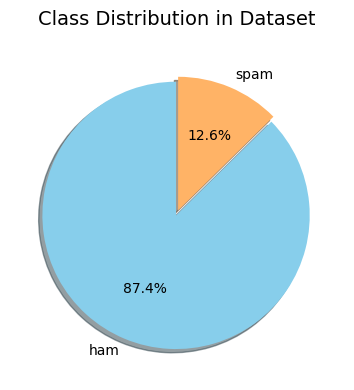

In [47]:
counts = df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

colors = ['#87CEEB', '#FFB366']

plt.figure(figsize=(4, 4))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.02]*len(counts),
    shadow=True
)

plt.title("Class Distribution in Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [48]:
# Chat / SMS slang dictionary
# Source: https://github.com/rishabhverma17/sms_slang_translator
# Used only for classical machine learning models
# Slang expansion is applied to improve lexical coverage in TF-IDF based models

chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing",
    "DUN": "don't"
}

In [49]:
# Function
def chat_conversion(text):
    tokens = []
    for t in text.split():
        key = t.upper()
        if key in chat_words:
            tokens.append(chat_words[key].lower())
        else:
            tokens.append(t)
    return " ".join(tokens)

In [50]:
# Required NLTK resources (on first run)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [51]:
# Performs core preprocessing, chat word expansion (classical ML only), 
# punctuation removal, tokenization, stopword removal, and lemmatization.
def classical_ml_preprocess(text):
    text = core_preprocess(text)
    text = chat_conversion(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [52]:
df['text_classical'] = df['text'].apply(classical_ml_preprocess)

pd.set_option('display.max_colwidth', 100)
print(df[['text', 'text_classical']].head())

                                                                                                  text  \
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...   
1                                                                        Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...   
3                                                    U dun say so early hor... U c already then say...   
4                                        Nah I don't think he goes to usf, he lives around here though   

                                                                                        text_classical  
0                   go jurong point crazy available bugis n great world la e buffet cine got amore wat  
1                                                                                ok lar joking wif oni  
2  free entry NUM wkly comp win fa cup final tkt

In [53]:
df.head()

,target,text,text_length,word_count,text_classical
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",111,20,go jurong point crazy available bugis n great world la e buffet cine got amore wat
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,155,28,free entry NUM wkly comp win fa cup final tkts NUM st may NUM text fa NUM receive entry question...
3,0,U dun say so early hor... U c already then say...,49,11,dont say early hor c already say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,13,nah dont think go usf life around though


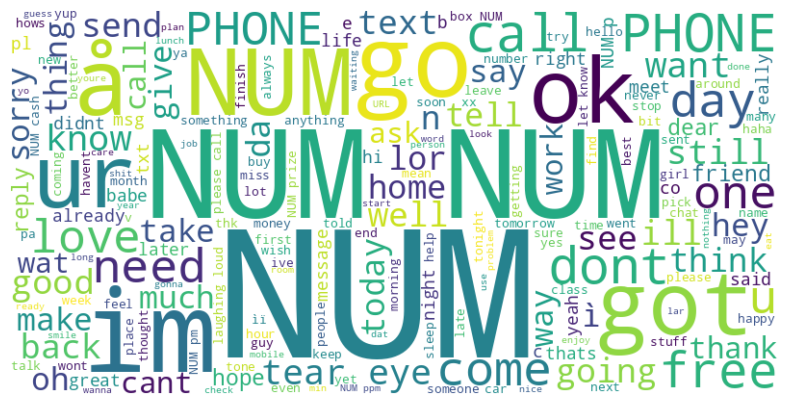

In [54]:
text_data = " ".join(df["text_classical"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [55]:
# =============================================================================
# GLOBAL TRAIN-TEST SPLIT (FOR ALL MODELS)
# =============================================================================
print("=" * 80)
print("CREATING UNIFIED TRAIN-TEST SPLIT FOR ALL MODELS")
print("=" * 80)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

# Index-based split — most reliable approach for reproducibility
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['target']
)

print(f"✓ Train size: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"✓ Test size:  {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)")
print(f"✓ Train class dist: {df.loc[train_idx, 'target'].value_counts(normalize=True).to_dict()}")
print(f"✓ Test class dist:  {df.loc[test_idx, 'target'].value_counts(normalize=True).to_dict()}")

# =============================================================================
# CLASSICAL ML FEATURES (CountVectorizer)
# =============================================================================
print("\n📊 Preparing features for Classical ML models...")

cv = CountVectorizer(min_df=0.0, max_df=1.0, binary=False, ngram_range=(1, 3))

# DATA LEAKAGE PREVENTION (R1 #8):
# CountVectorizer is fitted ONLY on train_idx.
# Vocabulary and document frequencies are derived exclusively from training data.
# X_test_cv uses transform() only — no frequency statistics from test set leak into the model.
X_train_cv = cv.fit_transform(df.loc[train_idx, "text_classical"])  # fit + transform on train only
X_test_cv  = cv.transform(df.loc[test_idx, "text_classical"])       # transform only — no fit

y_train_cv = df.loc[train_idx, "target"].values
y_test_cv  = df.loc[test_idx, "target"].values

# Leakage assertion: vocabulary must be set, test matrix columns must match train
assert cv.vocabulary_ is not None, "Leakage check: vocabulary not fitted"
assert X_train_cv.shape[1] == X_test_cv.shape[1], "Leakage check: feature dimension mismatch"

print(f"✓ Vocabulary size: {len(cv.vocabulary_)}")
print(f"✓ Train shape: {X_train_cv.shape}")
print(f"✓ Test shape:  {X_test_cv.shape}")
print(f"✓ Data leakage check passed: CountVectorizer fitted on train only")

# =============================================================================
# DEEP LEARNING FEATURES (Tokenizer + Padding)
# =============================================================================
print("\n🧠 Preparing features for Deep Learning models...")

MAX_WORDS = 10000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# DATA LEAKAGE PREVENTION (R1 #8):
# Tokenizer is fitted ONLY on train_idx texts.
# Word-to-index mapping is built exclusively from training vocabulary.
# Test sequences use texts_to_sequences() only — no vocabulary update from test set.
tokenizer.fit_on_texts(df.loc[train_idx, 'text'])  # fit on train only

# Train sequences
train_sequences = tokenizer.texts_to_sequences(df.loc[train_idx, 'text'])
X_train_dl = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Test sequences — tokenizer not re-fitted, OOV token handles unseen words
test_sequences = tokenizer.texts_to_sequences(df.loc[test_idx, 'text'])
X_test_dl = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_dl = df.loc[train_idx, "target"].values
y_test_dl  = df.loc[test_idx, "target"].values

# Leakage assertion: sequence dimensions must match
assert X_train_dl.shape[1] == X_test_dl.shape[1], "Leakage check: sequence length mismatch"

print(f"✓ Vocabulary size: {len(tokenizer.word_index)}")
print(f"✓ Train shape: {X_train_dl.shape}")
print(f"✓ Test shape:  {X_test_dl.shape}")
print(f"✓ OOV tokens: {tokenizer.word_index.get('<OOV>', 'Not found')}")
print(f"✓ Data leakage check passed: Tokenizer fitted on train only")
print("=" * 80 + "\n")

CREATING UNIFIED TRAIN-TEST SPLIT FOR ALL MODELS
✓ Train size: 4135 (80.0%)
✓ Test size:  1034 (20.0%)
✓ Train class dist: {0: 0.8737605804111246, 1: 0.12623941958887544}
✓ Test class dist:  {0: 0.8733075435203095, 1: 0.12669245647969052}

📊 Preparing features for Classical ML models...
✓ Vocabulary size: 57376
✓ Train shape: (4135, 57376)
✓ Test shape:  (1034, 57376)
✓ Data leakage check passed: CountVectorizer fitted on train only

🧠 Preparing features for Deep Learning models...
✓ Vocabulary size: 7816
✓ Train shape: (4135, 100)
✓ Test shape:  (1034, 100)
✓ OOV tokens: 1
✓ Data leakage check passed: Tokenizer fitted on train only



In [56]:
# CountVectorizer vocabulary boyutu
print(f"CountVectorizer vocabulary size: {len(cv.vocabulary_)}")

# Tokenizer vocabulary boyutu  
print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")

# Train/Test shape kontrolü
print(f"X_train_cv shape: {X_train_cv.shape}")
print(f"X_train_dl shape: {X_train_dl.shape}")

CountVectorizer vocabulary size: 57376
Tokenizer vocabulary size: 7816
X_train_cv shape: (4135, 57376)
X_train_dl shape: (4135, 100)


## Training with various models and predicting with them

## ML Models
### 1. LR (Logistic Regression)

📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Logistic Regression)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 4.2738 sec
✓ Best PR-AUC (CV): 0.9630
✓ Best Hyperparameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 0.1s
✓ Optimal Threshold (CV-based): 0.059
✓ Max MCC (CV): 0.9185
✓ CV Accuracy: 0.9821 ± 0.0032
✓ CV MCC:      0.9184 ± 0.0150

TRAINING FINAL LOGISTIC REGRESSION MODEL

⏳ Training final LR model with extended tracking...
✓ Final model training completed in 70.298 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LOGISTIC REGRESSION - FINAL RESULTS

✓ Accuracy (Threshold 0.06): 0.9826
✓ F1-Score:      0.9318
✓ ROC-AUC Score: 0.9911
✓ PR-AUC Score:  0.

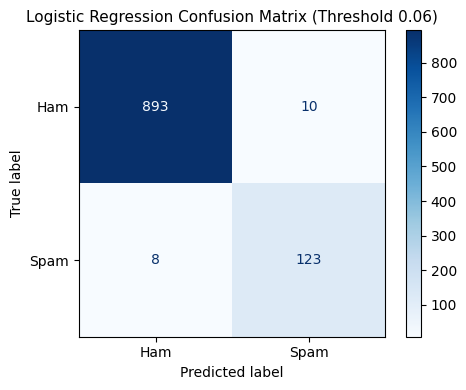

✅ LR saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              4.2738 sec
    Training:                 70.298 ms
    Inference:                279.925 ms
    Total Time:               4.6241 sec
    Latency (avg):            0.270720 ms/sample
    Training CO2:             0.000016 kg
    Training Energy:          0.000034 kWh
    Energy/1000 train (Wh):   0.008120 Wh
    Inference CO2:            0.000016 kg
    Energy/1000 pred (Wh):    0.033290 Wh
    CO2 per 1M predictions:   0.015466 kg
    Gap (Acc):                0.0174
    Gap (MCC):                0.0781


In [57]:
# ====================================================================================
# LOGISTIC REGRESSION (LR)
# ====================================================================================

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

lr_base = LogisticRegression(random_state=42)

lr_clf = GridSearchCV(
    lr_base,
    param_grid=lr_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (Logistic Regression)...")
timer.start("lr_grid")
lr_clf.fit(X_train, y_train)
lr_grid_time = timer.stop("lr_grid")

print(f"\n✓ Grid Search completed in {format_time(lr_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lr_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lr_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")
temp_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

temp_lr.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lr,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LOGISTIC REGRESSION MODEL")
print("=" * 80)

best_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

print("\n⏳ Training final LR model with extended tracking...")

training_metrics = track_model_training(
    model=best_lr,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="LR"
)

lr_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lr_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_lr,
    X_test,
    model_name="LR"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lr_pred_proba   = best_lr.predict_proba(X_test)[:, 1]
best_lr_predict = (lr_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (lr_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba      = best_lr.predict_proba(X_train)[:, 1]
best_lr_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy        = accuracy_score(y_train, best_lr_train_predict)
train_mcc             = matthews_corrcoef(y_train, best_lr_train_predict)

metrics = compute_metrics(y_test, best_lr_predict, lr_pred_proba)

# MCC-based generalization gap
mcc_gap = train_mcc - metrics["MCC"]

model_size_mb = get_model_size_mb(best_lr)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_lr_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Logistic Regression",
    threshold=optimal_threshold,
    cmap='Blues'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL 80 METRICS)
# ================================================================================
total_time = lr_grid_time + lr_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":   metrics["Accuracy"],
    "Precision":  metrics["Precision"],
    "Recall":     metrics["Recall"],
    "F1_Score":   metrics["F1_Score"],
    "MCC":        metrics["MCC"],
    "Kappa":      metrics["Kappa"],
    "ROC_AUC":    metrics["ROC_AUC"],
    "PR_AUC":     metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":        fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":         optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":     metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":          train_accuracy,
    "Test_Accuracy":           metrics["Accuracy"],
    "Generalization_Gap_Acc":  train_accuracy - metrics["Accuracy"],
    "Train_MCC":               train_mcc,
    "Test_MCC":                metrics["MCC"],
    "Generalization_Gap_MCC":  mcc_gap,

    # Timing
    "CV_Time":           lr_grid_time,
    "Training_Time":     lr_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":        inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":    inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":    inference_metrics['latency_p99_ms'],
    "Total_Time":        total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":          inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":      inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh":   inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":        inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":          training_metrics['gpu_used'],
    "RAM_Peak_MB":       training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":  inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":       model_size_mb,
    "Parameters_Count":    best_lr.coef_.size if hasattr(best_lr, 'coef_') else None,
    "Category":            "Classical",
    "Model_Format":        "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("LR", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(lr_grid_time)}")
print(f"    Training:                 {format_time(lr_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 2. NB (Naive Bayes)


NAIVE BAYES (NB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Naive Bayes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 125.796 ms
✓ Best PR-AUC (CV): 0.9674
✓ Best Hyperparameters: {'alpha': 1.0, 'fit_prior': False}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 0.0s
✓ Optimal Threshold (CV-based): 0.950
✓ Max MCC (CV): 0.8353
✓ CV Accuracy: 0.9574 ± 0.0071
✓ CV MCC:      0.8359 ± 0.0230

TRAINING FINAL NAIVE BAYES MODEL

⏳ Training final Naive Bayes model with extended tracking...
✓ Final model training completed in 3.106 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

NAIVE BAYES - FINAL RESULTS

✓ Accuracy (Threshold 0.95): 0.9836
✓ F1-Score:      0.9344
✓ ROC-AUC Score: 0.9841
✓ PR-AUC S

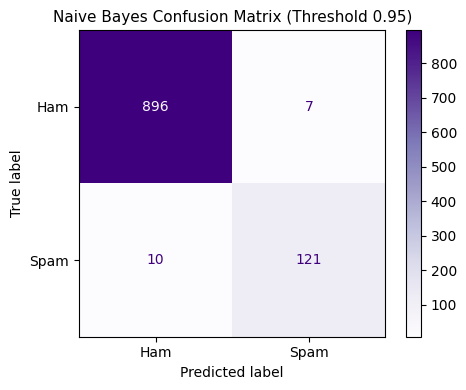

✅ NaiveBayes saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              125.796 ms
    Training:                 3.106 ms
    Inference:                197.203 ms
    Total Time:               326.105 ms
    Latency (avg):            0.190718 ms/sample
    Training CO2:             0.000015 kg
    Training Energy:          0.000032 kWh
    Energy/1000 train (Wh):   0.007674 Wh
    Inference CO2:            0.000010 kg
    Energy/1000 pred (Wh):    0.021478 Wh
    CO2 per 1M predictions:   0.009978 kg
    Gap (Acc):                0.0157
    Gap (MCC):                0.0717


In [59]:
# ====================================================================================
# NAIVE BAYES (NB) - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("NAIVE BAYES (NB) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False]
}

nb_base = MultinomialNB()

nb_clf = GridSearchCV(
    nb_base,
    param_grid=nb_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (Naive Bayes)...")
timer.start("nb_grid")
nb_clf.fit(X_train, y_train)
nb_grid_time = timer.stop("nb_grid")

print(f"\n✓ Grid Search completed in {format_time(nb_grid_time)}")
print(f"✓ Best PR-AUC (CV): {nb_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {nb_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_nb = MultinomialNB(**nb_clf.best_params_)
temp_nb.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_nb,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL NAIVE BAYES MODEL")
print("=" * 80)

best_nb = MultinomialNB(**nb_clf.best_params_)

print("\n⏳ Training final Naive Bayes model with extended tracking...")

training_metrics = track_model_training(
    model=best_nb,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="NaiveBayes"
)

nb_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(nb_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_nb,
    X_test,
    model_name="NaiveBayes"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

nb_pred_proba   = best_nb.predict_proba(X_test)[:, 1]
best_nb_predict = (nb_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (nb_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba      = best_nb.predict_proba(X_train)[:, 1]
best_nb_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy        = accuracy_score(y_train, best_nb_train_predict)
train_mcc             = matthews_corrcoef(y_train, best_nb_train_predict)

metrics   = compute_metrics(y_test, best_nb_predict, nb_pred_proba)
mcc_gap   = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_nb)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("NAIVE BAYES - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_nb_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Naive Bayes",
    threshold=optimal_threshold,
    cmap='Purples'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = nb_grid_time + nb_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":   metrics["Accuracy"],
    "Precision":  metrics["Precision"],
    "Recall":     metrics["Recall"],
    "F1_Score":   metrics["F1_Score"],
    "MCC":        metrics["MCC"],
    "Kappa":      metrics["Kappa"],
    "ROC_AUC":    metrics["ROC_AUC"],
    "PR_AUC":     metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":        fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            nb_grid_time,
    "Training_Time":      nb_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": best_nb.feature_count_.size if hasattr(best_nb, 'feature_count_') else None,
    "Category":         "Classical",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("NaiveBayes", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(nb_grid_time)}")
print(f"    Training:                 {format_time(nb_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 3. SVM (Support Vector Machines)


SVM - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (SVM)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Grid Search completed in 6.9391 sec
✓ Best PR-AUC (CV): 0.9645
✓ Best Hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 1.1s
✓ Optimal Threshold (CV-based): 0.177
✓ Max MCC (CV): 0.9216
✓ CV Accuracy: 0.9826 ± 0.0035
✓ CV MCC:      0.9216 ± 0.0161

TRAINING FINAL SVM MODEL

⏳ Training final SVM model with extended tracking...
✓ Final model training completed in 1.4199 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...

SVM - FINAL RESULTS

✓ Accuracy (Threshold 0.18): 0.9807
✓ F1-Score:      0.9248
✓ ROC-AUC Score: 0.9935
✓ PR-AUC Score:  0.9698
✓ MCC Score:   

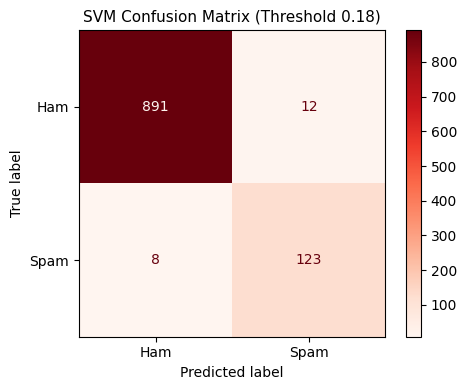

✅ SVM saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              6.9391 sec
    Training:                 1.4199 sec
    Inference:                502.978 ms
    Total Time:               8.8619 sec
    Latency (avg):            0.486439 ms/sample
    Training CO2:             0.000032 kg
    Training Energy:          0.000070 kWh
    Energy/1000 train (Wh):   0.016866 Wh
    Inference CO2:            0.000019 kg
    Energy/1000 pred (Wh):    0.039229 Wh
    CO2 per 1M predictions:   0.018225 kg
    Gap (Acc):                0.0193
    Gap (MCC):                0.0861


In [60]:
# ====================================================================================
# SVM - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("SVM - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_base = SVC(probability=True, random_state=42)

svm_clf = GridSearchCV(
    svm_base,
    param_grid=svm_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (SVM)...")
timer.start("svm_grid")
svm_clf.fit(X_train, y_train)
svm_grid_time = timer.stop("svm_grid")

print(f"\n✓ Grid Search completed in {format_time(svm_grid_time)}")
print(f"✓ Best PR-AUC (CV): {svm_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {svm_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_svm = SVC(
    **svm_clf.best_params_,
    probability=True,
    random_state=42
)
temp_svm.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_svm,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL SVM MODEL")
print("=" * 80)

best_svm = SVC(
    **svm_clf.best_params_,
    probability=True,
    random_state=42
)

print("\n⏳ Training final SVM model with extended tracking...")

training_metrics = track_model_training(
    model=best_svm,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="SVM"
)

svm_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(svm_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_svm,
    X_test,
    model_name="SVM"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

svm_pred_proba   = best_svm.predict_proba(X_test)[:, 1]
best_svm_predict = (svm_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (svm_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba       = best_svm.predict_proba(X_train)[:, 1]
best_svm_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy         = accuracy_score(y_train, best_svm_train_predict)
train_mcc              = matthews_corrcoef(y_train, best_svm_train_predict)

metrics       = compute_metrics(y_test, best_svm_predict, svm_pred_proba)
mcc_gap       = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_svm)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("SVM - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_svm_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="SVM",
    threshold=optimal_threshold,
    cmap='Reds'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = svm_grid_time + svm_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            svm_grid_time,
    "Training_Time":      svm_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": best_svm.n_support_.sum() if hasattr(best_svm, 'n_support_') else None,
    "Category":         "Classical",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("SVM", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(svm_grid_time)}")
print(f"    Training:                 {format_time(svm_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

In [61]:
# JSON'dan yükle
temp_results = load_results()

if temp_results:
    print(f"\n✅ {len(temp_results)} model JSON'a kaydedildi\n")
    
    # DataFrame oluştur
    temp_df = pd.DataFrame.from_dict(temp_results, orient='index')
    
    # En önemli metrikler
    cols_to_show = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'MCC', 
                    'ROC_AUC', 'Training_Time', 'Inference_Time_Sec']
    
    print(temp_df[cols_to_show].sort_values('MCC', ascending=False).to_string())
    
    print("\n" + "=" * 80)
    print("📊 ŞU ANA KADAR TAMAMLANAN MODELLER:")
    for model_name in temp_results.keys():
        print(f"   ✅ {model_name}")
    print("=" * 80 + "\n")
else:
    print("⚠️ Henüz sonuç yok!\n")


✅ 5 model JSON'a kaydedildi

              Accuracy  Precision    Recall  F1_Score       MCC   ROC_AUC  Training_Time  Inference_Time_Sec
NaiveBayes    0.983559   0.945312  0.923664  0.934363  0.925048  0.984086       0.003106            0.197203
LR            0.982592   0.924812  0.938931  0.931818  0.921876  0.991069       0.070298            0.279925
SVM           0.980658   0.911111  0.938931  0.924812  0.913852  0.993461       1.419853            0.502978
XGBoost       0.980658   0.930233  0.916031  0.923077  0.912051  0.984881       0.932182            0.617269
RandomForest  0.977756   0.928571  0.893130  0.910506  0.898033  0.988723       0.961899            4.386245

📊 ŞU ANA KADAR TAMAMLANAN MODELLER:
   ✅ LR
   ✅ NaiveBayes
   ✅ SVM
   ✅ RandomForest
   ✅ XGBoost



## Ensemble Models
### 1. RF (Random Forest)


RANDOM FOREST (RF) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Random Forest)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Grid Search completed in 10.8570 sec
✓ Best PR-AUC (CV): 0.9606
✓ Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 2.9s
✓ Optimal Threshold (CV-based): 0.186
✓ Max MCC (CV): 0.9070
✓ CV Accuracy: 0.9799 ± 0.0041
✓ CV MCC:      0.9070 ± 0.0192

TRAINING FINAL RANDOM FOREST MODEL

⏳ Training final Random Forest model with extended tracking...
✓ Final model training completed in 961.899 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

RANDOM FOREST - FINAL RESULTS

✓ Accu

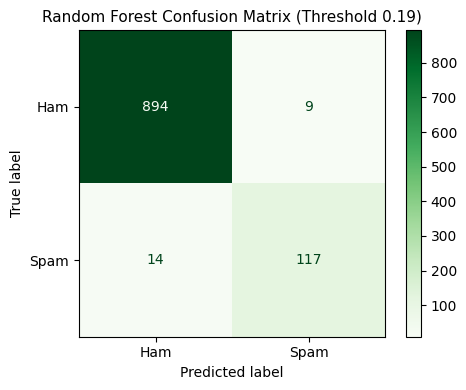

✅ RandomForest saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              10.8570 sec
    Training:                 961.899 ms
    Inference:                4.3862 sec
    Total Time:               16.2052 sec
    Latency (avg):            4.242017 ms/sample
    Training CO2:             0.000000 kg
    Training Energy:          0.000053 kWh
    Energy/1000 train (Wh):   0.012853 Wh
    Inference CO2:            0.000001 kg
    Energy/1000 pred (Wh):    0.206891 Wh
    CO2 per 1M predictions:   0.000815 kg
    Gap (Acc):                0.0048
    Gap (MCC):                0.0216


In [31]:
# ====================================================================================
# RANDOM FOREST (RF) - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("RANDOM FOREST (RF) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_base = RandomForestClassifier(random_state=42)

rf_clf = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (Random Forest)...")
timer.start("rf_grid")
rf_clf.fit(X_train, y_train)
rf_grid_time = timer.stop("rf_grid")

print(f"\n✓ Grid Search completed in {format_time(rf_grid_time)}")
print(f"✓ Best PR-AUC (CV): {rf_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {rf_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_rf = RandomForestClassifier(
    **rf_clf.best_params_,
    random_state=42
)
temp_rf.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_rf,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL RANDOM FOREST MODEL")
print("=" * 80)

best_rf = RandomForestClassifier(
    **rf_clf.best_params_,
    random_state=42
)

print("\n⏳ Training final Random Forest model with extended tracking...")

training_metrics = track_model_training(
    model=best_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="RandomForest"
)

rf_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(rf_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_rf,
    X_test,
    model_name="RandomForest"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

rf_pred_proba   = best_rf.predict_proba(X_test)[:, 1]
best_rf_predict = (rf_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (rf_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba      = best_rf.predict_proba(X_train)[:, 1]
best_rf_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy        = accuracy_score(y_train, best_rf_train_predict)
train_mcc             = matthews_corrcoef(y_train, best_rf_train_predict)

metrics       = compute_metrics(y_test, best_rf_predict, rf_pred_proba)
mcc_gap       = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_rf)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("RANDOM FOREST - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_rf_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Random Forest",
    threshold=optimal_threshold,
    cmap='Greens'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = rf_grid_time + rf_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            rf_grid_time,
    "Training_Time":      rf_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": int(best_rf.n_estimators * np.mean([t.tree_.node_count for t in best_rf.estimators_])) if hasattr(best_rf, 'estimators_') else None,
    "Category":         "Ensemble",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("RandomForest", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(rf_grid_time)}")
print(f"    Training:                 {format_time(rf_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 2. XGBoost (eXtreme Gradient Boosting)


XGBOOST (XGB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (XGBoost)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 20.7247 sec
✓ Best PR-AUC (CV): 0.9597
✓ Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.2, 'max_depth': 7, 'subsample': 1.0}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 1.7s
✓ Optimal Threshold (CV-based): 0.341
✓ Max MCC (CV): 0.8989
✓ CV Accuracy: 0.9780 ± 0.0027
✓ CV MCC:      0.8989 ± 0.0130

TRAINING FINAL XGBOOST MODEL

⏳ Training final XGBoost model with extended tracking...
✓ Final model training completed in 932.182 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

XGBOOST - FINAL RESULTS

✓ Accuracy (Threshold 0.34): 0.9807
✓ F1-Score:      0.9231
✓ 

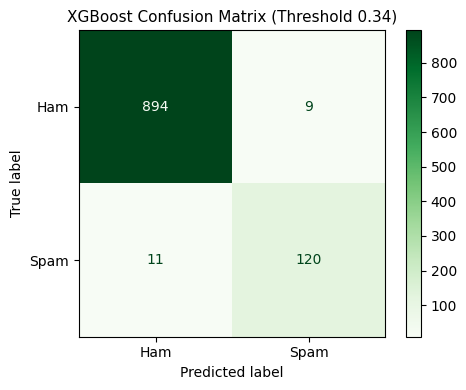

✅ XGBoost saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              20.7247 sec
    Training:                 932.182 ms
    Inference:                617.269 ms
    Total Time:               22.2742 sec
    Latency (avg):            0.596972 ms/sample
    Training CO2:             0.000000 kg
    Training Energy:          0.000045 kWh
    Energy/1000 train (Wh):   0.010947 Wh
    Inference CO2:            0.000000 kg
    Energy/1000 pred (Wh):    0.037108 Wh
    CO2 per 1M predictions:   0.000146 kg
    Gap (Acc):                0.0111
    Gap (MCC):                0.0504


In [32]:
# ====================================================================================
# XGBOOST (XGB) - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("XGBOOST (XGB) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
xgb_param_grid = {
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.1, 0.2],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.5, 0.8]
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

xgb_clf = GridSearchCV(
    xgb_base,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (XGBoost)...")
timer.start("xgb_grid")
xgb_clf.fit(X_train, y_train)
xgb_grid_time = timer.stop("xgb_grid")

print(f"\n✓ Grid Search completed in {format_time(xgb_grid_time)}")
print(f"✓ Best PR-AUC (CV): {xgb_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {xgb_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_xgb = XGBClassifier(
    **xgb_clf.best_params_,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)
temp_xgb.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_xgb,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL XGBOOST MODEL")
print("=" * 80)

best_xgb = XGBClassifier(
    **xgb_clf.best_params_,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

print("\n⏳ Training final XGBoost model with extended tracking...")

training_metrics = track_model_training(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="XGBoost"
)

xgb_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(xgb_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_xgb,
    X_test,
    model_name="XGBoost"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

xgb_pred_proba   = best_xgb.predict_proba(X_test)[:, 1]
best_xgb_predict = (xgb_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (xgb_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba       = best_xgb.predict_proba(X_train)[:, 1]
best_xgb_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy         = accuracy_score(y_train, best_xgb_train_predict)
train_mcc              = matthews_corrcoef(y_train, best_xgb_train_predict)

metrics       = compute_metrics(y_test, best_xgb_predict, xgb_pred_proba)
mcc_gap       = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_xgb)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("XGBOOST - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_xgb_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="XGBoost",
    threshold=optimal_threshold,
    cmap='Greens'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = xgb_grid_time + xgb_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            xgb_grid_time,
    "Training_Time":      xgb_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": best_xgb.n_estimators if hasattr(best_xgb, 'n_estimators') else None,
    "Category":         "Ensemble",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("XGBoost", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(xgb_grid_time)}")
print(f"    Training:                 {format_time(xgb_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 3. LightGBM (Light Gradient Boosting Machine)


LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (LightGBM)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 13.7363 sec
✓ Best PR-AUC (CV): 0.9605
✓ Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 0.5s
✓ Optimal Threshold (CV-based): 0.359
✓ Max MCC (CV): 0.9089
✓ CV Accuracy: 0.9802 ± 0.0039
✓ CV MCC:      0.9091 ± 0.0176

TRAINING FINAL LIGHTGBM MODEL

⏳ Training final LightGBM model with extended tracking...
✓ Final model training completed in 350.662 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LIGHTGBM - FINAL RESULTS

✓ Accuracy (Threshold 0.36): 0.9787
✓ F1-S

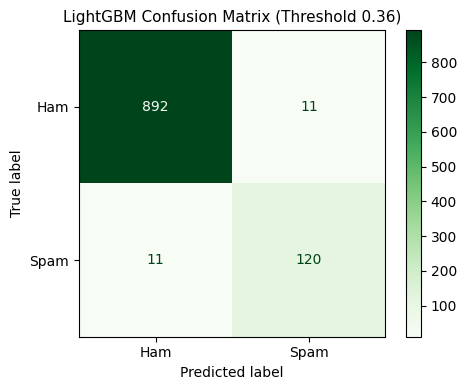

✅ LightGBM saved to JSON and CSV

💾 Timing and metrics stored successfully.
    Grid Search:              13.7363 sec
    Training:                 350.662 ms
    Inference:                105.8339 sec
    Total Time:               119.9208 sec
    Latency (avg):            102.353876 ms/sample
    Training CO2:             0.000011 kg
    Training Energy:          0.000023 kWh
    Energy/1000 train (Wh):   0.005607 Wh
    Inference CO2:            0.001636 kg
    Energy/1000 pred (Wh):    3.405981 Wh
    CO2 per 1M predictions:   1.582371 kg
    Gap (Acc):                0.0152
    Gap (MCC):                0.0685


In [36]:
# ====================================================================================
# LIGHTGBM (LGBM)
# ====================================================================================

print("\n" + "=" * 80)
print("LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

# LightGBM requires float32 for sparse matrix input
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
lgbm_param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.1, 0.2],
    'n_estimators':  [100],
    'num_leaves':    [31, 50],
    'subsample':     [0.8, 1.0]
}

lgbm_base = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

lgbm_clf = GridSearchCV(
    lgbm_base,
    param_grid=lgbm_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (LightGBM)...")
timer.start("lgbm_grid")
lgbm_clf.fit(X_train, y_train)
lgbm_grid_time = timer.stop("lgbm_grid")

print(f"\n✓ Grid Search completed in {format_time(lgbm_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lgbm_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lgbm_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)
temp_lgbm.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lgbm,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LIGHTGBM MODEL")
print("=" * 80)

best_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)

print("\n⏳ Training final LightGBM model with extended tracking...")

training_metrics = track_model_training(
    model=best_lgbm,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="LightGBM"
)

lgbm_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lgbm_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_lgbm,
    X_test,
    model_name="LightGBM"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lgbm_pred_proba   = best_lgbm.predict_proba(X_test)[:, 1]
best_lgbm_predict = (lgbm_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (lgbm_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba        = best_lgbm.predict_proba(X_train)[:, 1]
best_lgbm_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy          = accuracy_score(y_train, best_lgbm_train_predict)
train_mcc               = matthews_corrcoef(y_train, best_lgbm_train_predict)

metrics       = compute_metrics(y_test, best_lgbm_predict, lgbm_pred_proba)
mcc_gap       = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_lgbm)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LIGHTGBM - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_lgbm_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="LightGBM",
    threshold=optimal_threshold,
    cmap='Greens'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = lgbm_grid_time + lgbm_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            lgbm_grid_time,
    "Training_Time":      lgbm_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": best_lgbm.n_estimators if hasattr(best_lgbm, 'n_estimators') else None,
    "Category":         "Ensemble",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("LightGBM", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(lgbm_grid_time)}")
print(f"    Training:                 {format_time(lgbm_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

In [37]:
# JSON'dan yükle
temp_results = load_results()

if temp_results:
    print(f"\n✅ {len(temp_results)} model JSON'a kaydedildi\n")
    
    # DataFrame oluştur
    temp_df = pd.DataFrame.from_dict(temp_results, orient='index')
    
    # En önemli metrikler
    cols_to_show = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'MCC', 
                    'ROC_AUC', 'Training_Time', 'Inference_Time_Sec']
    
    print(temp_df[cols_to_show].sort_values('MCC', ascending=False).to_string())
    
    print("\n" + "=" * 80)
    print("📊 ŞU ANA KADAR TAMAMLANAN MODELLER:")
    for model_name in temp_results.keys():
        print(f"   ✅ {model_name}")
    print("=" * 80 + "\n")
else:
    print("⚠️ Henüz sonuç yok!\n")


✅ 9 model JSON'a kaydedildi

              Accuracy  Precision    Recall  F1_Score       MCC   ROC_AUC  Training_Time  Inference_Time_Sec
LSTM          0.984526   0.991453  0.885496  0.935484  0.928635  0.988900      22.334006           44.483296
NaiveBayes    0.983559   0.945312  0.923664  0.934363  0.925048  0.984086       0.003069            0.204123
LR            0.982592   0.924812  0.938931  0.931818  0.921876  0.991069       0.066767            0.279495
SVM           0.980658   0.911111  0.938931  0.924812  0.913852  0.993461       1.431901            0.517124
XGBoost       0.980658   0.930233  0.916031  0.923077  0.912051  0.984881       0.963296            0.643846
GRU           0.980658   0.991150  0.854962  0.918033  0.910320  0.984606      20.098846           44.571036
LightGBM      0.978723   0.916031  0.916031  0.916031  0.903849  0.987252       0.350662          105.833908
RandomForest  0.977756   0.928571  0.893130  0.910506  0.898033  0.988723       1.001574          

## DL Models
### 1. LSTM (Long Short-Term Memory)


LSTM MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------

1      0.9734     0.9819
2      0.9514     0.9843
3      0.9770     0.9879
4      0.9811     0.9819
5      0.9654     0.9831
------------------------------
✓ CV completed in 102.3964 sec
✓ Average PR-AUC (CV): 0.9697 (±0.0105)
✓ Average MCC   (CV): 0.9254 (±0.0102)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.416
✓ Max MCC (CV): 0.9299
✓ CV Accuracy: 0.9838 ± 0.0022
✓ CV MCC:      0.9254 ± 0.0102

TRAINING FINAL LSTM MODEL

⏳ Training final LSTM model with extended tracking...
Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9296 - loss: 0.2035 - val_accuracy: 0.9903 - val_

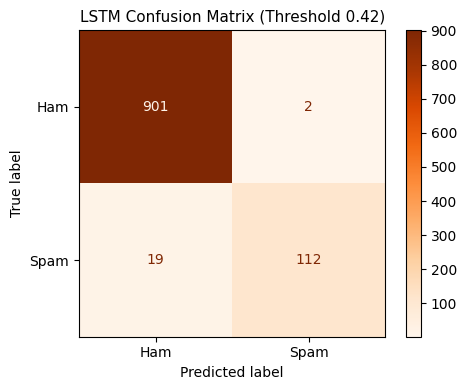

✅ LSTM saved to JSON and CSV

💾 Timing and metrics stored successfully.
    CV (Robustness):          102.3964 sec
    Final Training:           22.9646 sec
    Inference:                45.4226 sec
    Total Time:               170.7836 sec
    Latency (avg):            43.929030 ms/sample
    Training CO2:             0.000338 kg
    Training Energy:          0.000728 kWh
    Energy/1000 train (Wh):   0.176063 Wh
    Inference CO2:            0.000903 kg
    Energy/1000 pred (Wh):    1.879889 Wh
    CO2 per 1M predictions:   0.873370 kg
    Gap (Acc):                0.0102
    Gap (MCC):                0.0478


In [38]:
# ====================================================================================
# LSTM - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("LSTM MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_dl
X_test  = X_test_dl
y_train = y_train_dl
y_test  = y_test_dl

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Sequence length: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")
print(f"    Max vocabulary: {MAX_WORDS}")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("lstm_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    # Data split
    X_train_fold, X_val_fold = X_train[fold_train_idx], X_train[fold_val_idx]
    y_train_fold, y_val_fold = y_train[fold_train_idx], y_train[fold_val_idx]
    
    # Build & train
    model_cv = create_model('lstm')

    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )

    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )

    # Predict
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

lstm_cv_time = timer.stop("lstm_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(lstm_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LSTM MODEL")
print("=" * 80)

lstm_model = create_model('lstm')

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training final LSTM model with extended tracking...")

training_metrics = track_model_training(
    model=lstm_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="LSTM",
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

lstm_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lstm_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

class KerasWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        probs = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - probs, probs])

inference_wrapper = KerasWrapper(lstm_model)
inference_metrics = measure_inference_extended(
    inference_wrapper,
    X_test,
    model_name="LSTM"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lstm_pred_proba    = lstm_model.predict(X_test, verbose=0).flatten()
best_lstm_predict  = (lstm_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (lstm_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba       = lstm_model.predict(X_train, verbose=0).flatten()
best_lstm_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy          = accuracy_score(y_train, best_lstm_train_predict)
train_mcc               = matthews_corrcoef(y_train, best_lstm_train_predict)

metrics   = compute_metrics(y_test, best_lstm_predict, lstm_pred_proba)
mcc_gap   = train_mcc - metrics["MCC"]

# Model size
model_size_mb  = 0
temp_filename  = "temp_lstm_model_size.keras"
try:
    lstm_model.save(temp_filename, include_optimizer=False)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LSTM MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_lstm_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="LSTM",
    threshold=optimal_threshold,
    cmap='Oranges'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = lstm_cv_time + lstm_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            lstm_cv_time,
    "Training_Time":      lstm_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": lstm_model.count_params() if hasattr(lstm_model, 'count_params') else None,
    "Category":         "Deep Learning",
    "Model_Format":     "keras",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": MAX_WORDS,

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("LSTM", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(lstm_cv_time)}")
print(f"    Final Training:           {format_time(lstm_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 2. GRU (Gated Recurrent Unit)


GRU MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9708     0.9843
2      0.9592     0.9831
3      0.9658     0.9782
4      0.9914     0.9903
5      0.9718     0.9819
------------------------------
✓ CV completed in 131.5291 sec
✓ Average PR-AUC (CV): 0.9718 (±0.0107)
✓ Average MCC   (CV): 0.9252 (±0.0181)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.574
✓ Max MCC (CV): 0.9324
✓ CV Accuracy: 0.9836 ± 0.0039
✓ CV MCC:      0.9252 ± 0.0181

TRAINING FINAL GRU MODEL

⏳ Training final GRU model with extended tracking...
Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.9218 - loss: 0.2439 - val_accuracy: 0.9807 - val_loss

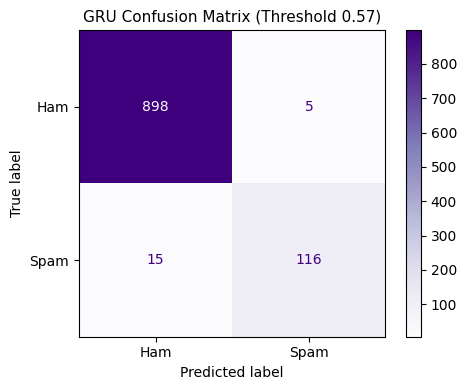

✅ GRU saved to JSON and CSV

💾 Timing and metrics stored successfully.
    CV (Robustness):          131.5291 sec
    Final Training:           25.3054 sec
    Inference:                45.7387 sec
    Total Time:               202.5732 sec
    Latency (avg):            44.234697 ms/sample
    Training CO2:             0.000525 kg
    Training Energy:          0.001131 kWh
    Energy/1000 train (Wh):   0.273455 Wh
    Inference CO2:            0.000704 kg
    Energy/1000 pred (Wh):    1.465955 Wh
    CO2 per 1M predictions:   0.681062 kg
    Gap (Acc):                0.0085
    Gap (MCC):                0.0400


In [39]:
# ====================================================================================
# GRU - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("GRU MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_dl
X_test  = X_test_dl
y_train = y_train_dl
y_test  = y_test_dl

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Sequence length: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")
print(f"    Max vocabulary: {MAX_WORDS}")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("gru_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    # Data split
    X_train_fold, X_val_fold = X_train[fold_train_idx], X_train[fold_val_idx]
    y_train_fold, y_val_fold = y_train[fold_train_idx], y_train[fold_val_idx]

    # Build & train model
    model_cv = create_model('gru')

    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )

    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )

    # Predict probabilities
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

gru_cv_time = timer.stop("gru_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(gru_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL GRU MODEL")
print("=" * 80)

gru_model = create_model('gru')

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training final GRU model with extended tracking...")

training_metrics = track_model_training(
    model=gru_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="GRU",
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

gru_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(gru_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

class KerasWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        probs = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - probs, probs])

inference_wrapper = KerasWrapper(gru_model)
inference_metrics = measure_inference_extended(
    inference_wrapper,
    X_test,
    model_name="GRU"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

gru_pred_proba   = gru_model.predict(X_test, verbose=0).flatten()
best_gru_predict = (gru_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (gru_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba       = gru_model.predict(X_train, verbose=0).flatten()
best_gru_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy         = accuracy_score(y_train, best_gru_train_predict)
train_mcc              = matthews_corrcoef(y_train, best_gru_train_predict)

metrics   = compute_metrics(y_test, best_gru_predict, gru_pred_proba)
mcc_gap   = train_mcc - metrics["MCC"]

# Model size
model_size_mb = 0
temp_filename = "temp_gru_model_size.keras"
try:
    gru_model.save(temp_filename, include_optimizer=False)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("GRU MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_gru_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="GRU",
    threshold=optimal_threshold,
    cmap='Purples'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = gru_cv_time + gru_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            gru_cv_time,
    "Training_Time":      gru_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": gru_model.count_params() if hasattr(gru_model, 'count_params') else None,
    "Category":         "Deep Learning",
    "Model_Format":     "keras",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": MAX_WORDS,

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("GRU", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(gru_cv_time)}")
print(f"    Final Training:           {format_time(gru_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 3. CNN (Convolutional Neural Network)


CNN MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9581     0.9758
2      0.9601     0.9686
3      0.9581     0.9661
4      0.9717     0.9734
5      0.9657     0.9807
------------------------------
✓ CV completed in 30.0988 sec
✓ Average PR-AUC (CV): 0.9628 (±0.0053)
✓ Average MCC   (CV): 0.8846 (±0.0200)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.901
✓ Max MCC (CV): 0.9194
✓ CV Accuracy: 0.9729 ± 0.0052
✓ CV MCC:      0.8846 ± 0.0200

TRAINING FINAL CNN MODEL

⏳ Training final CNN model with extended tracking...
Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8699 - loss: 0.3897 - val_accuracy: 0.9686 - val_loss: 0

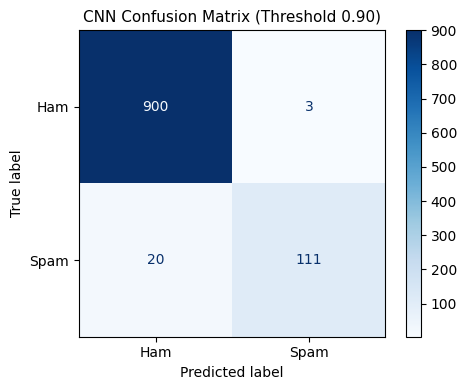

  ✅ CNN → JSON+CSV

💾 Timing and metrics stored successfully.
    CV (Robustness):          30.0988 sec
    Final Training:           6.1216 sec
    Inference:                41.3334 sec
    Total Time:               77.5539 sec
    Latency (avg):            39.974246 ms/sample
    Training CO2:             0.000103 kg
    Training Energy:          0.000223 kWh
    Energy/1000 train (Wh):   0.053821 Wh
    Inference CO2:            0.000744 kg
    Energy/1000 pred (Wh):    1.548003 Wh
    CO2 per 1M predictions:   0.719180 kg
    Gap (Acc):                0.0179
    Gap (MCC):                0.0839


In [63]:
# ====================================================================================
# CNN - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("CNN MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_dl
X_test  = X_test_dl
y_train = y_train_dl
y_test  = y_test_dl

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Sequence length: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")
print(f"    Max vocabulary: {MAX_WORDS}")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("cnn_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    X_train_fold, X_val_fold = X_train[fold_train_idx], X_train[fold_val_idx]
    y_train_fold, y_val_fold = y_train[fold_train_idx], y_train[fold_val_idx]

    # Build & train model
    model_cv = create_model('cnn')

    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )

    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )

    # Predict probabilities
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

cnn_cv_time = timer.stop("cnn_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(cnn_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL CNN MODEL")
print("=" * 80)

cnn_model = create_model('cnn')

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training final CNN model with extended tracking...")

training_metrics = track_model_training(
    model=cnn_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="CNN",
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

cnn_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(cnn_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

class KerasWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        probs = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - probs, probs])

inference_wrapper = KerasWrapper(cnn_model)
inference_metrics = measure_inference_extended(
    inference_wrapper,
    X_test,
    model_name="CNN"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

cnn_pred_proba   = cnn_model.predict(X_test, verbose=0).flatten()
best_cnn_predict = (cnn_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (cnn_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
train_pred_proba       = cnn_model.predict(X_train, verbose=0).flatten()
best_cnn_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy         = accuracy_score(y_train, best_cnn_train_predict)
train_mcc              = matthews_corrcoef(y_train, best_cnn_train_predict)

metrics   = compute_metrics(y_test, best_cnn_predict, cnn_pred_proba)
mcc_gap   = train_mcc - metrics["MCC"]

# Model size
model_size_mb = 0
temp_filename = "temp_cnn_model_size.keras"
try:
    cnn_model.save(temp_filename, include_optimizer=False)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("CNN MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_cnn_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="CNN",
    threshold=optimal_threshold,
    cmap='Blues'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = cnn_cv_time + cnn_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            cnn_cv_time,
    "Training_Time":      cnn_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": cnn_model.count_params() if hasattr(cnn_model, 'count_params') else None,
    "Category":         "Deep Learning",
    "Model_Format":     "keras",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": MAX_WORDS,

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("CNN", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(cnn_cv_time)}")
print(f"    Final Training:           {format_time(cnn_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 4. DISTILBERT (Distilled Bidirectional Encoder Representations from Transformers)

In [ ]:
# ====================================================================================
# DISTILBERT - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("DISTILBERT MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
from sklearn.model_selection import train_test_split as _tts_bert
_train_idx_bert, _test_idx_bert = _tts_bert(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

train_texts = df.loc[_train_idx_bert, 'text']
test_texts  = df.loc[_test_idx_bert, 'text']
y_train     = df.loc[_train_idx_bert, 'target'].values
y_test      = df.loc[_test_idx_bert, 'target'].values

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {len(y_train)}")
print(f"    Test samples:  {len(y_test)}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

assert len(y_train) == 4135, f"Train size mismatch: {len(y_train)} != 4135"
assert len(y_test)  == 1034, f"Test size mismatch: {len(y_test)} != 1034"

# ================================================================================
# TOKENIZATION
# ================================================================================
print("\n⏳ Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_texts(texts, tokenizer, max_len=128):
    """Encode texts for DistilBERT model."""
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='tf'
    )

print("⏳ Encoding full dataset...")
X_train_bert = encode_texts(train_texts, bert_tokenizer)
X_test_bert  = encode_texts(test_texts, bert_tokenizer)
print("✓ Tokenization completed")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("bert_cv")

train_input_ids      = X_train_bert['input_ids'].numpy()
train_attention_mask = X_train_bert['attention_mask'].numpy()

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (train_idx_fold, val_idx) in enumerate(kfold.split(train_input_ids, y_train), 1):
    # Data split
    X_train_fold_ids  = train_input_ids[train_idx_fold]
    X_train_fold_mask = train_attention_mask[train_idx_fold]
    X_val_fold_ids    = train_input_ids[val_idx]
    X_val_fold_mask   = train_attention_mask[val_idx]

    y_train_fold = y_train[train_idx_fold]
    y_val_fold   = y_train[val_idx]

    # Build & train model
    tf.keras.backend.clear_session()
    model_cv = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    )
    model_cv.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model_cv.fit(
        {'input_ids': X_train_fold_ids, 'attention_mask': X_train_fold_mask},
        y_train_fold,
        epochs=3,
        batch_size=16,
        verbose=0
    )

    # Predict probabilities
    val_logits = model_cv.predict(
        {'input_ids': X_val_fold_ids, 'attention_mask': X_val_fold_mask},
        verbose=0
    ).logits

    val_probs = tf.nn.softmax(val_logits, axis=1).numpy()[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

bert_cv_time = timer.stop("bert_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(bert_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL DISTILBERT MODEL")
print("=" * 80)

tf.keras.backend.clear_session()
distilbert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
distilbert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n⏳ Training final DistilBERT model with extended tracking...")

# Training energy tracker
process      = psutil.Process(os.getpid())
ram_baseline = process.memory_info().rss / (1024 * 1024)

if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(
        project_name="SMS_Spam_DistilBERT",
        log_level="error"
    )
    tracker.start()

early_stop_bert = EarlyStopping(
    monitor='loss',
    patience=1,
    restore_best_weights=True,
    verbose=1
)

timer.start("bert_train")
history = distilbert_model.fit(
    {'input_ids':      X_train_bert['input_ids'],
     'attention_mask': X_train_bert['attention_mask']},
    y_train,
    epochs=3,
    batch_size=16,
    callbacks=[early_stop_bert],
    verbose=1
)
bert_training_time = timer.stop("bert_train")

training_co2_kg     = 0.0
training_energy_kwh = 0.0
if CODECARBON_AVAILABLE:
    try:
        training_co2_kg = float(tracker.stop() or 0.0)
        if hasattr(tracker, 'final_emissions_data') and tracker.final_emissions_data:
            training_energy_kwh = float(tracker.final_emissions_data.energy_consumed)
    except Exception as e:
        print(f"⚠️ CodeCarbon training tracking error: {e}")

# RAM and hardware metrics
ram_peak    = process.memory_info().rss / (1024 * 1024)
cpu_percent = psutil.cpu_percent(interval=0.1)

gpu_used      = False
gpu_memory_mb = None
try:
    import GPUtil
    gpus = GPUtil.getGPUs()
    if gpus:
        gpu_used      = True
        gpu_memory_mb = gpus[0].memoryUsed
except:
    pass

n_train = len(y_train)
energy_per_1000_train_wh = (training_energy_kwh * 1e6) / n_train if n_train > 0 else 0.0

training_metrics = {
    "training_co2_kg":          training_co2_kg,
    "training_energy_kwh":      training_energy_kwh,
    "energy_per_1000_train_wh": energy_per_1000_train_wh,
    "training_time":            bert_training_time,
    "CEF_kg_per_kWh":           CEF_KG_PER_KWH,
    "CEF_gCO2_per_kWh":         CEF_GCO2_PER_KWH,
    "ram_baseline_mb":          ram_baseline,
    "ram_peak_mb":              ram_peak,
    "cpu_utilization":          cpu_percent,
    "gpu_used":                 gpu_used,
    "gpu_memory_mb":            gpu_memory_mb,
}

print(f"✓ Final model training completed in {format_time(bert_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

# Warm-up
distilbert_model.predict({
    'input_ids':      X_test_bert['input_ids'][:5],
    'attention_mask': X_test_bert['attention_mask'][:5]
}, verbose=0)

ram_before_inf = process.memory_info().rss / (1024 * 1024)

if CODECARBON_AVAILABLE:
    inf_tracker = EmissionsTracker(
        project_name="SMS_Spam_DistilBERT_inference",
        log_level="error"
    )
    inf_tracker.start()

# Per-sample latency loop
latencies = []
for i in range(len(y_test)):
    t0 = time.perf_counter()
    distilbert_model.predict({
        'input_ids':      X_test_bert['input_ids'][i:i+1],
        'attention_mask': X_test_bert['attention_mask'][i:i+1]
    }, verbose=0)
    latencies.append((time.perf_counter() - t0) * 1000)

latencies = np.array(latencies)

inference_co2_kg     = 0.0
inference_energy_kwh = 0.0
if CODECARBON_AVAILABLE:
    try:
        inference_co2_kg = float(inf_tracker.stop() or 0.0)
        if hasattr(inf_tracker, 'final_emissions_data') and inf_tracker.final_emissions_data:
            inference_energy_kwh = float(inf_tracker.final_emissions_data.energy_consumed)
    except Exception as e:
        print(f"⚠️ CodeCarbon inference tracking error: {e}")

ram_after_inf    = process.memory_info().rss / (1024 * 1024)
ram_inference_mb = max(0.0, ram_after_inf - ram_before_inf)

n_test = len(y_test)
energy_per_1000_pred_wh = (inference_energy_kwh * 1e6) / n_test if n_test > 0 else 0.0
co2_per_1M_pred_kg      = (inference_co2_kg / n_test) * 1_000_000 if n_test > 0 else 0.0

inference_metrics = {
    "inference_time_total": float(np.sum(latencies) / 1000),
    "latency_mean_ms":      float(np.mean(latencies)),
    "latency_median_ms":    float(np.median(latencies)),
    "latency_std_ms":       float(np.std(latencies)),
    "latency_min_ms":       float(np.min(latencies)),
    "latency_max_ms":       float(np.max(latencies)),
    "latency_p50_ms":       float(np.percentile(latencies, 50)),
    "latency_p95_ms":       float(np.percentile(latencies, 95)),
    "latency_p99_ms":       float(np.percentile(latencies, 99)),
    "inference_co2_kg":     inference_co2_kg,
    "inference_energy_kwh": inference_energy_kwh,
    "energy_per_1000_pred_wh": energy_per_1000_pred_wh,
    "co2_per_1M_pred_kg":      co2_per_1M_pred_kg,
    "ram_inference_mb":     ram_inference_mb,
}

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

test_logits     = distilbert_model.predict({
    'input_ids':      X_test_bert['input_ids'],
    'attention_mask': X_test_bert['attention_mask']
}, verbose=0).logits

bert_pred_proba  = tf.nn.softmax(test_logits, axis=1).numpy()[:, 1]
best_bert_predict = (bert_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (bert_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis
print("⏳ Calculating train predictions for generalization gap analysis...")
train_logits = distilbert_model.predict({
    'input_ids':      X_train_bert['input_ids'],
    'attention_mask': X_train_bert['attention_mask']
}, verbose=0).logits

train_proba             = tf.nn.softmax(train_logits, axis=1).numpy()[:, 1]
best_bert_train_predict = (train_proba >= optimal_threshold).astype(int)
train_accuracy          = accuracy_score(y_train, best_bert_train_predict)
train_mcc               = matthews_corrcoef(y_train, best_bert_train_predict)

metrics = compute_metrics(y_test, best_bert_predict, bert_pred_proba)
mcc_gap = train_mcc - metrics["MCC"]

# Model size
model_size_mb = 0
temp_dir = "distilbert_temp"
try:
    distilbert_model.save_pretrained(temp_dir)
    model_size_mb = sum(
        os.path.getsize(os.path.join(temp_dir, f))
        for f in os.listdir(temp_dir)
    ) / (1024 * 1024)
    shutil.rmtree(temp_dir)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("DISTILBERT MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.4f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_bert_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="DistilBERT",
    threshold=optimal_threshold,
    cmap='viridis'
)

# ================================================================================
# SAVE TO JSON + CSV (SINGLE DICT WITH ALL METRICS)
# ================================================================================
total_time = bert_cv_time + bert_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results_dict = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            bert_cv_time,
    "Training_Time":      bert_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": 66955010,
    "Category":         "Deep Learning",
    "Model_Format":     "tf_savedmodel",

    # Dataset info
    "Training_Samples":       len(y_train),
    "Test_Samples":           len(y_test),
    "Feature_Count_or_Vocab": 30522,

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# Save to JSON + CSV
save_model_result("DistilBERT", model_results_dict)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(bert_cv_time)}")
print(f"    Final Training:           {format_time(bert_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results_dict['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results_dict['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

In [112]:
temp_results = load_results()

if temp_results:
    print(f"\n✅ {len(temp_results)} model JSON'a kaydedildi\n")
    
    # DataFrame oluştur
    temp_df = pd.DataFrame.from_dict(temp_results, orient='index')
    
    # En önemli metrikler
    cols_to_show = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'MCC', 
                    'ROC_AUC', 'Training_Time', 'Inference_Time_Sec']
    
    print(temp_df[cols_to_show].sort_values('MCC', ascending=False).to_string())
    
    print("\n" + "=" * 80)
    print("📊 ŞU ANA KADAR TAMAMLANAN MODELLER:")
    for model_name in temp_results.keys():
        print(f"   ✅ {model_name}")
    print("=" * 80 + "\n")
else:
    print("⚠️ Henüz sonuç yok!\n")


✅ 9 model JSON'a kaydedildi

              Accuracy  Precision    Recall  F1_Score       MCC   ROC_AUC  Training_Time  Inference_Time_Sec
LSTM          0.984526   0.991453  0.885496  0.935484  0.928635  0.988900      22.334006           44.483296
NaiveBayes    0.983559   0.945312  0.923664  0.934363  0.925048  0.984086       0.001888            0.207178
LR            0.982592   0.924812  0.938931  0.931818  0.921876  0.991069       0.046866            0.263969
SVM           0.980658   0.911111  0.938931  0.924812  0.913852  0.993461       1.471712            0.507710
XGBoost       0.980658   0.930233  0.916031  0.923077  0.912051  0.984881       0.854973            0.625533
GRU           0.980658   0.991150  0.854962  0.918033  0.910320  0.984606      20.098846           44.571036
LightGBM      0.978723   0.916031  0.916031  0.916031  0.903849  0.987252       0.375873          104.559475
RandomForest  0.977756   0.928571  0.893130  0.910506  0.898033  0.988723       0.414747          

In [113]:
# =============================================================================
# STORE DATASET STATISTICS FOR REPORT
# =============================================================================

# Extract target values from the global dataframe
y_array = df['target'].values

# Determine Vocabulary Size
# Priority: Deep Learning Tokenizer > CountVectorizer > Default 0
if 'tokenizer' in globals():
    vocab_size = len(tokenizer.word_index)
elif 'cv' in globals():
    vocab_size = len(cv.vocabulary_)
else:
    vocab_size = 0

dataset_stats = {
    'total_messages': len(df),
    
    # Class Distribution (Ham=0, Spam=1)
    'ham_count': int((y_array == 0).sum()),
    'spam_count': int((y_array == 1).sum()),
    
    'ham_percentage': float((y_array == 0).sum() / len(y_array) * 100),
    'spam_percentage': float((y_array == 1).sum() / len(y_array) * 100),
    
    # Split Sizes (Based on Global Indices)
    'train_size': len(train_idx),
    'test_size': len(test_idx),
    
    # Text Features
    'vocabulary_size': vocab_size,
    'max_sequence_length': MAX_LEN,
    
    # Feature Dimension (For Classical ML)
    'feature_dim': X_train_cv.shape[1] if 'X_train_cv' in globals() else 0,
    
    # Model Counts Breakdown
    'total_models': 10,      # Total count of trained models
    'classical_models': 3,   # LR, SVM, NB
    'ensemble_models': 3,    # RF, XGBoost, LightGBM
    'deep_learning_models': 4 # LSTM, GRU, CNN, DistilBERT
}

# =============================================================================
# PRINT STATISTICS
# =============================================================================
print("=" * 80)
print(" Dataset Statistics Saved Successfully ")
print("=" * 80)
print(f"  • Total Messages:     {dataset_stats['total_messages']}")
print(f"  • Ham Messages:       {dataset_stats['ham_count']} ({dataset_stats['ham_percentage']:.2f}%)")
print(f"  • Spam Messages:      {dataset_stats['spam_count']} ({dataset_stats['spam_percentage']:.2f}%)")
print("-" * 80)
print(f"  • Train Set Size:     {dataset_stats['train_size']}")
print(f"  • Test Set Size:      {dataset_stats['test_size']}")
print(f"  • Vocabulary Size:    {dataset_stats['vocabulary_size']}")
print(f"  • Max Sequence Len:   {dataset_stats['max_sequence_length']}")
print("-" * 80)
print(f"  • Total Models:       {dataset_stats['total_models']}")
print(f"    - Classical:        {dataset_stats['classical_models']}")
print(f"    - Ensemble:         {dataset_stats['ensemble_models']}")
print(f"    - Deep Learning:    {dataset_stats['deep_learning_models']}")
print("=" * 80 + "\n")

 Dataset Statistics Saved Successfully 
  • Total Messages:     5169
  • Ham Messages:       4516 (87.37%)
  • Spam Messages:      653 (12.63%)
--------------------------------------------------------------------------------
  • Train Set Size:     4135
  • Test Set Size:      1034
  • Vocabulary Size:    7816
  • Max Sequence Len:   100
--------------------------------------------------------------------------------
  • Total Models:       10
    - Classical:        3
    - Ensemble:         3
    - Deep Learning:    4



## Comparison Models

### 1. Performance Metrics Table

In [114]:
# ====================================================================================
# LOAD RESULTS FROM JSON
# ====================================================================================
model_results = load_results()

if not model_results:
    print("⚠️ No results found. Please train models first.")
else:
    print(f"✅ Loaded {len(model_results)} models from JSON")
    print(f"   Models: {', '.join(model_results.keys())}")

✅ Loaded 9 models from JSON
   Models: LR, NaiveBayes, SVM, RandomForest, XGBoost, LightGBM, LSTM, GRU, CNN


In [115]:
# ====================================================================================
# HÜCRE 1: PERFORMANCE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)")
print("=" * 120)

# Prepare data
performance_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Accuracy": metrics.get("Accuracy", 0),
        "Precision": metrics.get("Precision", 0),
        "Recall": metrics.get("Recall", 0),
        "F1-Score": metrics.get("F1_Score", 0),
        "MCC": metrics.get("MCC", 0),
        "Kappa": metrics.get("Kappa", 0),
        "ROC-AUC": metrics.get("ROC_AUC", 0),
        "PR-AUC": metrics.get("PR_AUC", 0),
        "Specificity": metrics.get("Specificity", 0),
        "FPR": metrics.get("FPR", 0)
    }
    performance_data.append(row)

# Create DataFrame
df_performance = pd.DataFrame(performance_data)

# Sort by MCC (primary), F1-Score (secondary), Precision (tertiary)
df_performance = df_performance.sort_values(
    by=["MCC", "F1-Score", "Precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Add rank
df_performance.insert(0, "Rank", range(1, len(df_performance) + 1))

# Display table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_performance.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE AVERAGE PERFORMANCE:")
print("-" * 100)
summary_perf = df_performance.groupby("Category")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "MCC", "ROC-AUC"]
].mean().sort_values(by="MCC", ascending=False)
print(summary_perf.to_string(float_format="%.4f"))
print("-" * 100)

# Champion model
champion = df_performance.iloc[0]
print("\n" + "=" * 120)
print(f"🏆 CHAMPION MODEL: {champion['Model'].upper()}")
print("-" * 120)
print(f"   Category:      {champion['Category']}")
print(f"   MCC:           {champion['MCC']:.4f}")
print(f"   F1-Score:      {champion['F1-Score']:.4f}")
print(f"   Accuracy:      {champion['Accuracy']:.4f}")
print(f"   ROC-AUC:       {champion['ROC-AUC']:.4f}")
print("=" * 120)


PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)
 Rank        Model      Category  Accuracy  Precision  Recall  F1-Score    MCC  Kappa  ROC-AUC  PR-AUC  Specificity    FPR
    1         LSTM Deep Learning    0.9845     0.9915  0.8855    0.9355 0.9286 0.9267   0.9889  0.9693       0.9989 0.0011
    2   NaiveBayes     Classical    0.9836     0.9453  0.9237    0.9344 0.9250 0.9250   0.9841  0.9680       0.9922 0.0078
    3           LR     Classical    0.9826     0.9248  0.9389    0.9318 0.9219 0.9218   0.9911  0.9666       0.9889 0.0111
    4          SVM     Classical    0.9807     0.9111  0.9389    0.9248 0.9139 0.9137   0.9935  0.9698       0.9867 0.0133
    5      XGBoost      Ensemble    0.9807     0.9302  0.9160    0.9231 0.9121 0.9120   0.9849  0.9671       0.9900 0.0100
    6          GRU Deep Learning    0.9807     0.9912  0.8550    0.9180 0.9103 0.9071   0.9846  0.9639       0.9989 0.0011
    7     LightGBM      Ensemble    0.9787     0.9160  0.9160    0.9160 0.9038 0.9038   0.

### 2. Efficiency & Mobile Metrics Table

In [116]:
# ====================================================================================
# HÜCRE 2: EFFICIENCY & MOBILE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)")
print("=" * 120)

# Prepare data
efficiency_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Model Size (MB)": metrics.get("Model_Size_MB", 0),
        "RAM Inference (MB)": metrics.get("RAM_Inference_MB", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0)
    }
    efficiency_data.append(row)

# Create DataFrame
df_efficiency = pd.DataFrame(efficiency_data)

# Sort by Latency p95 (ascending - lower is better)
df_efficiency = df_efficiency.sort_values(
    by=["Latency p95 (ms)", "Model Size (MB)"],
    ascending=[True, True]
).reset_index(drop=True)

# Add rank
df_efficiency.insert(0, "Rank", range(1, len(df_efficiency) + 1))

# Display table
print(df_efficiency.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📱 CATEGORY-WISE EFFICIENCY SUMMARY:")
print("-" * 100)
summary_eff = df_efficiency.groupby("Category")[
    ["Model Size (MB)", "RAM Inference (MB)", "Latency Mean (ms)", "Latency p95 (ms)"]
].mean().sort_values(by="Latency p95 (ms)", ascending=True)
print(summary_eff.to_string(float_format="%.4f"))
print("-" * 100)

# Most efficient model
most_efficient = df_efficiency.iloc[0]
print("\n" + "=" * 120)
print(f"⚡ MOST EFFICIENT MODEL (Mobile): {most_efficient['Model'].upper()}")
print("-" * 120)
print(f"   Category:          {most_efficient['Category']}")
print(f"   Latency p95:       {most_efficient['Latency p95 (ms)']:.4f} ms")
print(f"   Model Size:        {most_efficient['Model Size (MB)']:.4f} MB")
print(f"   RAM (Inference):   {most_efficient['RAM Inference (MB)']:.2f} MB")
print("=" * 120)


EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)
 Rank        Model      Category  Model Size (MB)  RAM Inference (MB)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)  Training Time (s)  Inference Time (s)
    1   NaiveBayes     Classical           1.7517              0.0625             0.2004            0.2502            0.2846             0.0019              0.2072
    2           LR     Classical           0.4386              0.0156             0.2553            0.2792            0.3337             0.0469              0.2640
    3          SVM     Classical           0.3440              0.4531             0.4910            0.5353            0.5590             1.4717              0.5077
    4      XGBoost      Ensemble           0.1324              0.5117             0.6050            0.6573            0.7357             0.8550              0.6255
    5 RandomForest      Ensemble           0.8720              0.0078             4.3468            4.5415          

### 3. Sustainability Metrics Table

In [70]:
# ====================================================================================
# HÜCRE 3: SUSTAINABILITY METRICS TABLE
# ====================================================================================
print("\n" + "=" * 120)
print("SUSTAINABILITY & ENERGY METRICS (Sorted by Inference CO2 Emissions)")
print("=" * 120)

sustainability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":                     model_name,
        "Category":                  metrics.get("Category", "Unknown"),
        # Training energy (CodeCarbon measured)
        "Training CO2 (kg)":         metrics.get("Training_CO2_kg", 0),
        "Training Energy (kWh)":     metrics.get("Training_Energy_kWh", 0),
        "Energy/1000 train (Wh)":    metrics.get("Energy_per_1000_train_Wh", 0),
        # Inference energy (CodeCarbon measured)
        "Inference CO2 (kg)":        metrics.get("Inference_CO2_kg", 0),
        "Inference Energy (kWh)":    metrics.get("Inference_Energy_kWh", 0),
        "Energy/1000 pred (Wh)":     metrics.get("Energy_per_1000_pred_Wh", 0),
        # Table 7 metric (R1 #9)
        "CO2/1M pred (kg)":          metrics.get("CO2_per_1M_pred_kg", 0),
        # CEF (R1 #7)
        "CEF (gCO2/kWh)":            metrics.get("CEF_gCO2_per_kWh", 465),
        # Timing
        "Training Time (s)":         metrics.get("Training_Time", 0),
        "CV Time (s)":               metrics.get("CV_Time", 0),
        "Total Time (s)":            metrics.get("Total_Time", 0),
        "GPU Used":                  "Yes" if metrics.get("GPU_Used", False) else "No"
    }
    sustainability_data.append(row)

df_sustainability = pd.DataFrame(sustainability_data)

# Sort by Inference CO2 (ascending - lower is better)
df_sustainability = df_sustainability.sort_values(
    by=["Inference CO2 (kg)", "Inference Energy (kWh)"],
    ascending=[True, True]
).reset_index(drop=True)

df_sustainability.insert(0, "Rank", range(1, len(df_sustainability) + 1))

print(df_sustainability.to_string(index=False, float_format="%.6f"))
print("=" * 120)

# Category-wise summary
print("\n🌍 CATEGORY-WISE SUSTAINABILITY SUMMARY:")
print("-" * 100)
summary_sust = df_sustainability.groupby("Category")[
    ["Training CO2 (kg)", "Inference CO2 (kg)", "Energy/1000 pred (Wh)", "CO2/1M pred (kg)"]
].mean().sort_values(by="Inference CO2 (kg)", ascending=True)
print(summary_sust.to_string(float_format="%.6f"))
print("-" * 100)

# Most sustainable model
most_sustainable = df_sustainability.iloc[0]
print("\n" + "=" * 120)
print(f"🌱 MOST SUSTAINABLE MODEL: {most_sustainable['Model'].upper()}")
print("-" * 120)
print(f"   Category:                  {most_sustainable['Category']}")
print(f"   Training CO2:              {most_sustainable['Training CO2 (kg)']:.6f} kg")
print(f"   Inference CO2:             {most_sustainable['Inference CO2 (kg)']:.6f} kg")
print(f"   Energy/1000 pred (Wh):     {most_sustainable['Energy/1000 pred (Wh)']:.6f} Wh")
print(f"   CO2 per 1M predictions:    {most_sustainable['CO2/1M pred (kg)']:.4f} kg")
print(f"   CEF:                       {most_sustainable['CEF (gCO2/kWh)']:.0f} gCO2/kWh (IEA 2024, Turkey)")
print(f"   Total Time:                {most_sustainable['Total Time (s)']:.2f} s")
print("=" * 120)


SUSTAINABILITY & ENERGY METRICS (Sorted by Inference CO2 Emissions)
 Rank        Model      Category  Training CO2 (kg)  Training Energy (kWh)  Energy/1000 train (Wh)  Inference CO2 (kg)  Inference Energy (kWh)  Energy/1000 pred (Wh)  CO2/1M pred (kg)  CEF (gCO2/kWh)  Training Time (s)  CV Time (s)  Total Time (s) GPU Used
    1           LR     Classical           0.000098               0.000210                0.050906            0.000027                0.000059               0.056844          0.026409      465.000000           0.046866     0.434429        0.745265       No
    2      XGBoost      Ensemble           0.000041               0.000089                0.021580            0.000029                0.000063               0.060956          0.028319      465.000000           0.854973    21.153986       22.634491       No
    3          SVM     Classical           0.000051               0.000110                0.026624            0.000059                0.000126               0.1

### 4. Statistical Rigor & Stability Table

In [71]:
# ====================================================================================
# HÜCRE 4: STATISTICAL RIGOR & STABILITY TABLE
# ====================================================================================
print("\n" + "=" * 120)
print("STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)")
print("=" * 120)

stability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":                model_name,
        "Category":             metrics.get("Category", "Unknown"),
        "CV Acc Mean":          metrics.get("CV_Accuracy_Mean", 0),
        "CV Acc Std":           metrics.get("CV_Accuracy_Std", 0),
        "CV MCC Mean":          metrics.get("CV_MCC_Mean", 0),
        "CV MCC Std":           metrics.get("CV_MCC_Std", 0),
        "Train Accuracy":       metrics.get("Train_Accuracy", 0),
        "Test Accuracy":        metrics.get("Test_Accuracy", 0),
        # FIX: key renamed from Generalization_Gap to Generalization_Gap_Acc
        "Gen. Gap (Acc)":       metrics.get("Generalization_Gap_Acc", 0),
        # NEW: MCC-based generalization gap (R1 #8)
        "Train MCC":            metrics.get("Train_MCC", 0),
        "Test MCC":             metrics.get("Test_MCC", 0),
        "Gen. Gap (MCC)":       metrics.get("Generalization_Gap_MCC", 0),
        "Optimal Threshold":    metrics.get("Optimal_Threshold", 0),
        "Threshold Improvement": metrics.get("Threshold_Improvement", 0)
    }
    stability_data.append(row)

df_stability = pd.DataFrame(stability_data)

# Sort by Generalization Gap Acc (ascending - lower is better)
df_stability = df_stability.sort_values(
    by=["Gen. Gap (Acc)", "CV Acc Std"],
    ascending=[True, True]
).reset_index(drop=True)

df_stability.insert(0, "Rank", range(1, len(df_stability) + 1))

print(df_stability.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE STABILITY SUMMARY:")
print("-" * 100)
summary_stab = df_stability.groupby("Category")[
    ["CV Acc Mean", "CV Acc Std", "CV MCC Mean", "CV MCC Std",
     "Gen. Gap (Acc)", "Gen. Gap (MCC)"]
].mean().sort_values(by="Gen. Gap (Acc)", ascending=True)
print(summary_stab.to_string(float_format="%.4f"))
print("-" * 100)

# Most stable model
most_stable = df_stability.iloc[0]
print("\n" + "=" * 120)
print(f"🎯 MOST STABLE MODEL (Best Generalization): {most_stable['Model'].upper()}")
print("-" * 120)
print(f"   Category:                  {most_stable['Category']}")
print(f"   Generalization Gap (Acc):  {most_stable['Gen. Gap (Acc)']:.4f}")
print(f"   Generalization Gap (MCC):  {most_stable['Gen. Gap (MCC)']:.4f}")
print(f"   CV Accuracy:               {most_stable['CV Acc Mean']:.4f} ± {most_stable['CV Acc Std']:.4f}")
print(f"   CV MCC:                    {most_stable['CV MCC Mean']:.4f} ± {most_stable['CV MCC Std']:.4f}")
print("=" * 120)


STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)
 Rank        Model      Category  CV Acc Mean  CV Acc Std  CV MCC Mean  CV MCC Std  Train Accuracy  Test Accuracy  Gen. Gap (Acc)  Train MCC  Test MCC  Gen. Gap (MCC)  Optimal Threshold  Threshold Improvement
    1 RandomForest      Ensemble       0.9799      0.0041       0.9070      0.0192          0.9826         0.9778          0.0048     0.9196    0.8980          0.0216             0.1864                 0.0513
    2          GRU Deep Learning       0.9797      0.0050       0.9089      0.0189          0.9894         0.9807          0.0087     0.9511    0.9103          0.0408             0.5940                 0.0000
    3      XGBoost      Ensemble       0.9780      0.0027       0.8989      0.0130          0.9918         0.9807          0.0111     0.9624    0.9121          0.0504             0.3409                 0.0019
    4         LSTM Deep Learning       0.9833      0.0065       0.9244      0.0279          0.

### 5. Performance Visualization


GENERATING PERFORMANCE VISUALIZATIONS...


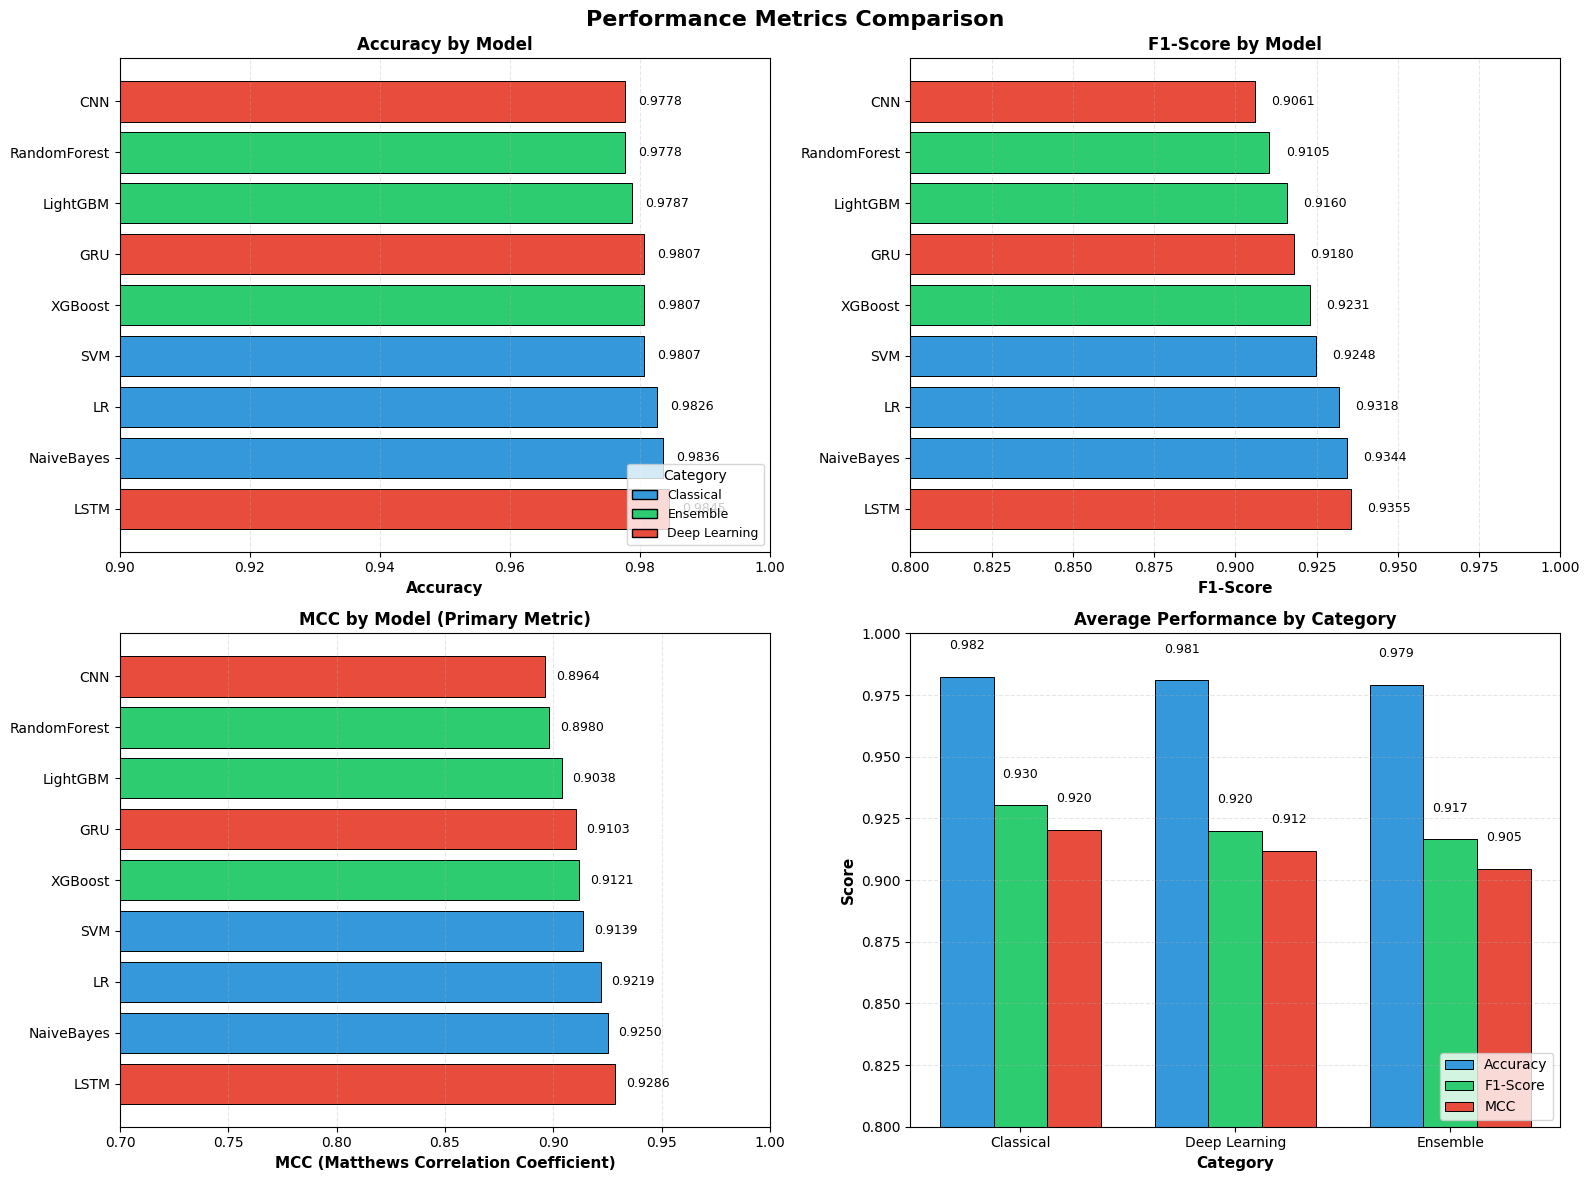

✓ Performance visualizations generated successfully!


In [72]:
# ====================================================================================
# HÜCRE 5: PERFORMANCE VISUALIZATION
# ====================================================================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 80)
print("GENERATING PERFORMANCE VISUALIZATIONS...")
print("=" * 80)

# Prepare data from model_results
models = []
categories = []
accuracy = []
f1_scores = []
mcc_scores = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    f1_scores.append(metrics.get("F1_Score", 0))
    mcc_scores.append(metrics.get("MCC", 0))

# Create DataFrame for easier plotting
df_viz = pd.DataFrame({
    'Model': models,
    'Category': categories,
    'Accuracy': accuracy,
    'F1-Score': f1_scores,
    'MCC': mcc_scores
})

# Sort by MCC
df_viz = df_viz.sort_values('MCC', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Metrics Comparison', fontsize=16, fontweight='bold')

# Color mapping for categories
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_viz['Category']]

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(df_viz['Model'], df_viz['Accuracy'], color=colors, edgecolor='black', linewidth=0.7)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy by Model', fontsize=12, fontweight='bold')
ax1.set_xlim([0.9, 1.0])
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['Accuracy']):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 2: F1-Score comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(df_viz['Model'], df_viz['F1-Score'], color=colors, edgecolor='black', linewidth=0.7)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score by Model', fontsize=12, fontweight='bold')
ax2.set_xlim([0.8, 1.0])
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['F1-Score']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 3: MCC comparison
ax3 = axes[1, 0]
bars3 = ax3.barh(df_viz['Model'], df_viz['MCC'], color=colors, edgecolor='black', linewidth=0.7)
ax3.set_xlabel('MCC (Matthews Correlation Coefficient)', fontsize=11, fontweight='bold')
ax3.set_title('MCC by Model (Primary Metric)', fontsize=12, fontweight='bold')
ax3.set_xlim([0.7, 1.0])
ax3.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['MCC']):
    ax3.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 4: Category-wise grouped comparison
ax4 = axes[1, 1]
category_summary = df_viz.groupby('Category')[['Accuracy', 'F1-Score', 'MCC']].mean()
x_pos = np.arange(len(category_summary))
width = 0.25

bars_acc = ax4.bar(x_pos - width, category_summary['Accuracy'], width, 
                   label='Accuracy', color='#3498db', edgecolor='black', linewidth=0.7)
bars_f1 = ax4.bar(x_pos, category_summary['F1-Score'], width, 
                  label='F1-Score', color='#2ecc71', edgecolor='black', linewidth=0.7)
bars_mcc = ax4.bar(x_pos + width, category_summary['MCC'], width, 
                   label='MCC', color='#e74c3c', edgecolor='black', linewidth=0.7)

ax4.set_xlabel('Category', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Average Performance by Category', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(category_summary.index, fontsize=10)
ax4.legend(loc='lower right', fontsize=10)
ax4.set_ylim([0.8, 1.0])
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars_acc, bars_f1, bars_mcc]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Legend for categories (add to first plot)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance visualizations generated successfully!")

### 6. Efficiency Trade-offs


GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...


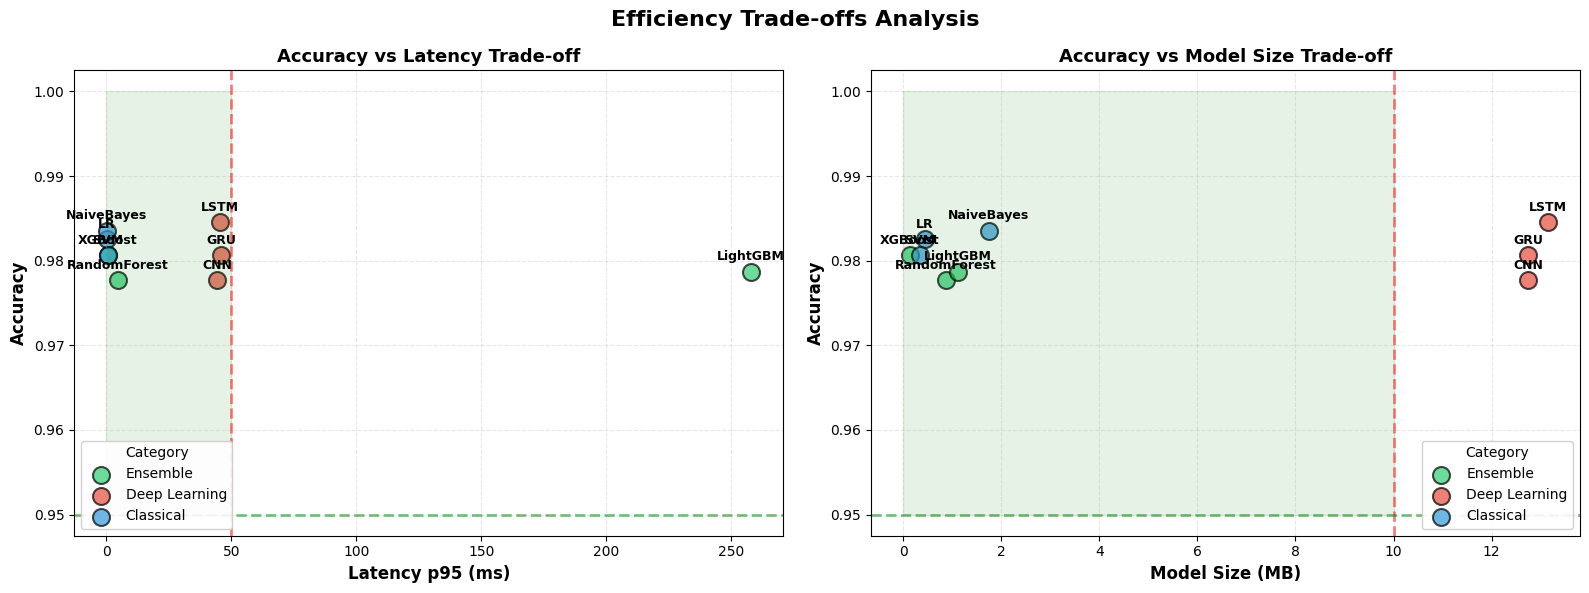

✓ Efficiency trade-off visualizations generated successfully!


In [73]:
# ====================================================================================
# HÜCRE 6: EFFICIENCY TRADE-OFFS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models = []
categories = []
accuracy = []
latency_p95 = []
model_size = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    latency_p95.append(metrics.get("Latency_p95_ms", 0))
    model_size.append(metrics.get("Model_Size_MB", 0))

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Efficiency Trade-offs Analysis', fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Plot 1: Accuracy vs Latency (p95)
ax1 = axes[0]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    lat_cat = [l for l, m in zip(latency_p95, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax1.scatter(lat_cat, acc_cat, s=150, alpha=0.7, 
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax1.annotate(model, (lat_cat[i], acc_cat[i]), 
                    textcoords="offset points", xytext=(0,8), 
                    ha='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('Latency p95 (ms)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Latency Trade-off', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower left', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Latency < 50ms, Accuracy > 0.95)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (50ms)')
ax1.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax1.fill_between([0, 50], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

# Plot 2: Accuracy vs Model Size
ax2 = axes[1]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    size_cat = [s for s, m in zip(model_size, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax2.scatter(size_cat, acc_cat, s=150, alpha=0.7,
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax2.annotate(model, (size_cat[i], acc_cat[i]),
                    textcoords="offset points", xytext=(0,8),
                    ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy vs Model Size Trade-off', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='lower right', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Size < 10MB, Accuracy > 0.95)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (10MB)')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax2.fill_between([0, 10], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

plt.tight_layout()
plt.savefig('efficiency_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Efficiency trade-off visualizations generated successfully!")

### 7. Sustainability Analysis


GENERATING SUSTAINABILITY VISUALIZATIONS...


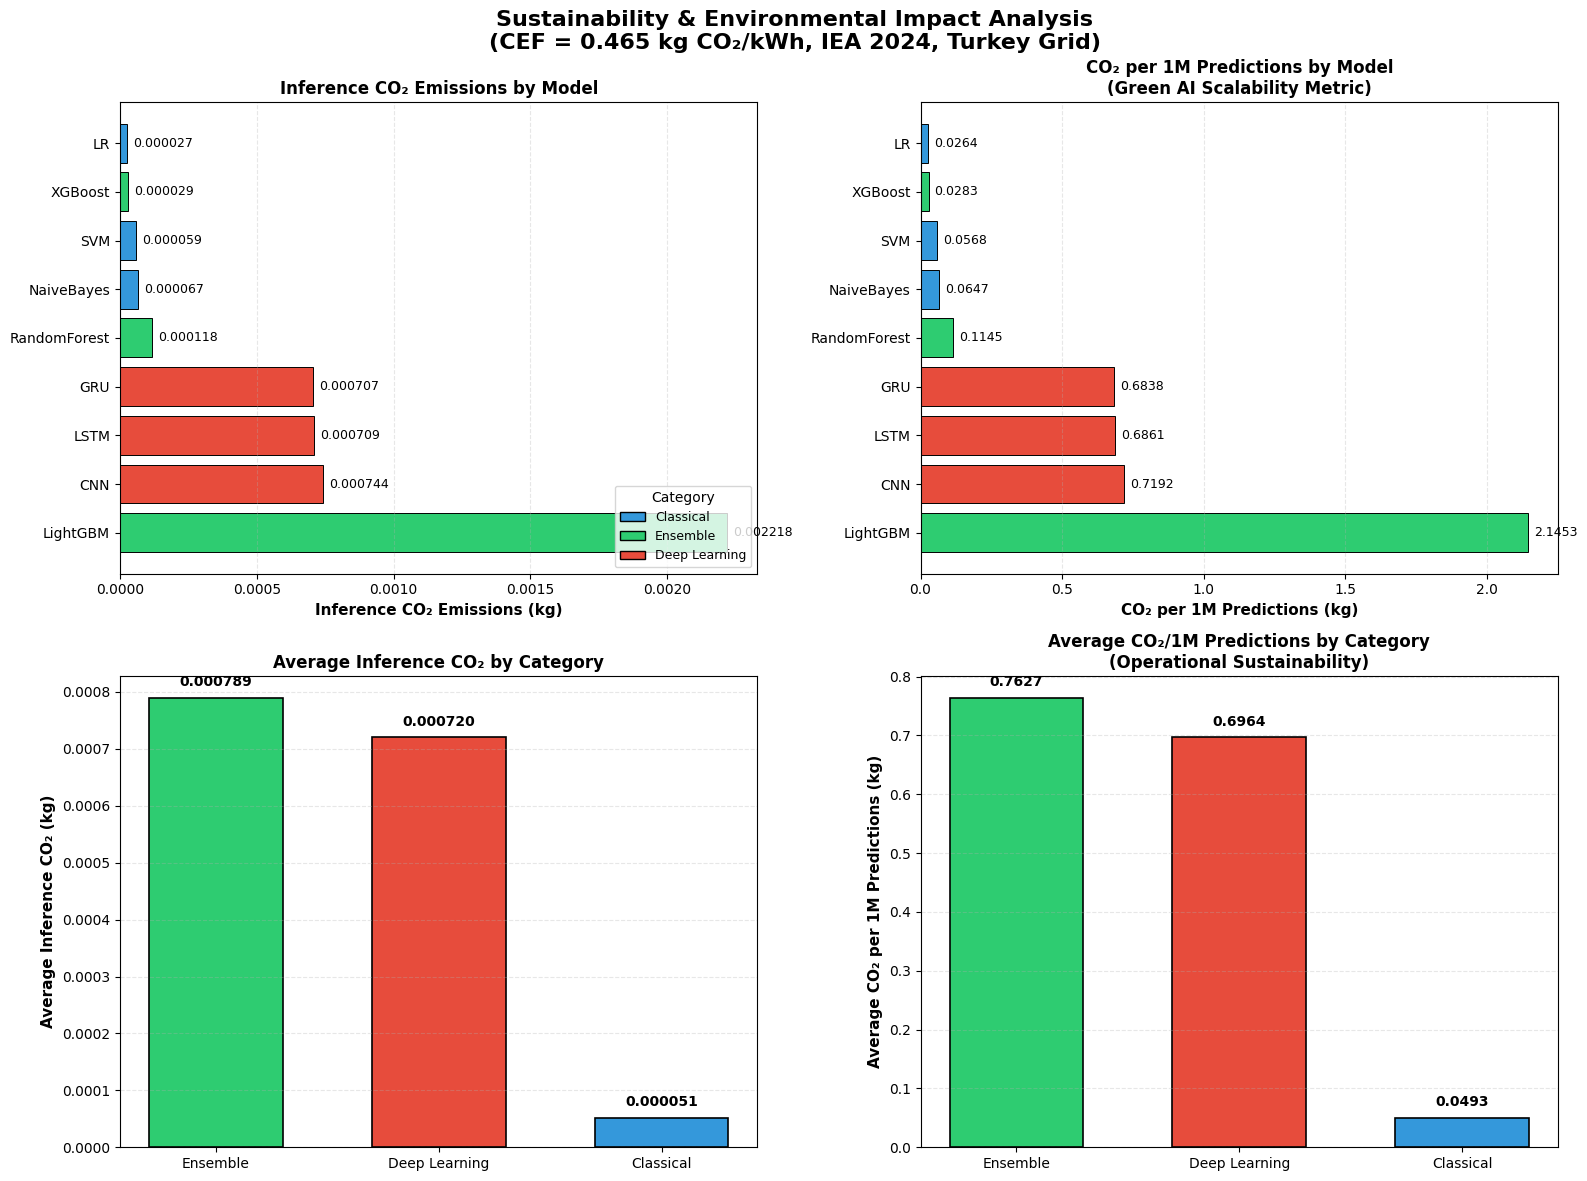

✓ Sustainability visualizations generated successfully!

📊 Summary:
   Most sustainable (inference):  LR (0.000027 kg CO₂)
   Least sustainable (inference): LightGBM (0.002218 kg CO₂)
   Average inference CO₂:         0.000520 kg
   Average CO₂/1M predictions:    0.5028 kg
   CEF (IEA 2024, Turkey):         0.465 kg CO₂/kWh = 465 gCO₂/kWh


In [74]:
# ====================================================================================
# HÜCRE 7: SUSTAINABILITY ANALYSIS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING SUSTAINABILITY VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models        = []
categories    = []
training_co2  = []
inference_co2 = []
co2_per_1M    = []
energy_kwh    = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    # FIX: split into training and inference CO2
    training_co2.append(metrics.get("Training_CO2_kg", 0))
    inference_co2.append(metrics.get("Inference_CO2_kg", 0))
    co2_per_1M.append(metrics.get("CO2_per_1M_pred_kg", 0))
    energy_kwh.append(metrics.get("Inference_Energy_kWh", 0))

# Create DataFrame
df_sust = pd.DataFrame({
    'Model':            models,
    'Category':         categories,
    'Training CO2 (kg)': training_co2,
    'Inference CO2 (kg)': inference_co2,
    'CO2/1M pred (kg)': co2_per_1M,
    'Inference Energy (kWh)': energy_kwh,
})

# Sort by Inference CO2 (descending for chart — highest at top)
df_sust = df_sust.sort_values('Inference CO2 (kg)', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sustainability & Environmental Impact Analysis\n(CEF = 0.465 kg CO₂/kWh, IEA 2024, Turkey Grid)',
             fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical':     '#3498db',
    'Ensemble':      '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_sust['Category']]

# Plot 1: Inference CO2 by model
ax1 = axes[0, 0]
ax1.barh(df_sust['Model'], df_sust['Inference CO2 (kg)'], color=colors,
         edgecolor='black', linewidth=0.7)
ax1.set_xlabel('Inference CO₂ Emissions (kg)', fontsize=11, fontweight='bold')
ax1.set_title('Inference CO₂ Emissions by Model', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['Inference CO2 (kg)']):
    ax1.text(v + max(df_sust['Inference CO2 (kg)']) * 0.01, i,
             f'{v:.6f}', va='center', fontsize=9)

# Plot 2: CO2 per 1M predictions (R1 #9 — Table 7 metric)
ax2 = axes[0, 1]
ax2.barh(df_sust['Model'], df_sust['CO2/1M pred (kg)'], color=colors,
         edgecolor='black', linewidth=0.7)
ax2.set_xlabel('CO₂ per 1M Predictions (kg)', fontsize=11, fontweight='bold')
ax2.set_title('CO₂ per 1M Predictions by Model\n(Green AI Scalability Metric)',
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['CO2/1M pred (kg)']):
    ax2.text(v + max(df_sust['CO2/1M pred (kg)']) * 0.01, i,
             f'{v:.4f}', va='center', fontsize=9)

# Plot 3: Category-wise Inference CO2 comparison
ax3 = axes[1, 0]
category_co2 = df_sust.groupby('Category')['Inference CO2 (kg)'].mean().sort_values(ascending=False)
colors_cat   = [category_colors.get(cat, '#95a5a6') for cat in category_co2.index]
bars3 = ax3.bar(category_co2.index, category_co2.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average Inference CO₂ (kg)', fontsize=11, fontweight='bold')
ax3.set_title('Average Inference CO₂ by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_co2.values):
    ax3.text(i, v + max(category_co2.values) * 0.02, f'{v:.6f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Category-wise CO2/1M predictions
ax4 = axes[1, 1]
category_1m   = df_sust.groupby('Category')['CO2/1M pred (kg)'].mean().sort_values(ascending=False)
colors_cat    = [category_colors.get(cat, '#95a5a6') for cat in category_1m.index]
bars4 = ax4.bar(category_1m.index, category_1m.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax4.set_ylabel('Average CO₂ per 1M Predictions (kg)', fontsize=11, fontweight='bold')
ax4.set_title('Average CO₂/1M Predictions by Category\n(Operational Sustainability)',
              fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_1m.values):
    ax4.text(i, v + max(category_1m.values) * 0.02, f'{v:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat)
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('sustainability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sustainability visualizations generated successfully!")
print("\n📊 Summary:")
print(f"   Most sustainable (inference):  {df_sust.iloc[-1]['Model']} "
      f"({df_sust.iloc[-1]['Inference CO2 (kg)']:.6f} kg CO₂)")
print(f"   Least sustainable (inference): {df_sust.iloc[0]['Model']} "
      f"({df_sust.iloc[0]['Inference CO2 (kg)']:.6f} kg CO₂)")
print(f"   Average inference CO₂:         {df_sust['Inference CO2 (kg)'].mean():.6f} kg")
print(f"   Average CO₂/1M predictions:    {df_sust['CO2/1M pred (kg)'].mean():.4f} kg")
print(f"   CEF (IEA 2024, Turkey):         0.465 kg CO₂/kWh = 465 gCO₂/kWh")
print("=" * 80)

### 8. Time Analysis


COMPREHENSIVE TIME & EFFICIENCY ANALYSIS

📊 DETAILED TIME BREAKDOWN:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  CV Time (s)  Training Time (s)  Inference Time (s)  Total Time (s)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)
  NaiveBayes     Classical       0.1127             0.0021              0.1932          0.3080             0.1868            0.1962            0.2067
          LR     Classical       0.4344             0.0469              0.2640          0.7453             0.2553            0.2792            0.3337
         SVM     Classical      10.2936             1.4717              0.5077         12.2730             0.4910            0.5353            0.5590
RandomForest      Ensemble      11.4924             0.4147              4.4946         16.4017             4.3468            4.5415            4.9893
     XGBoost      Ensemble      21.1540             0.8550 

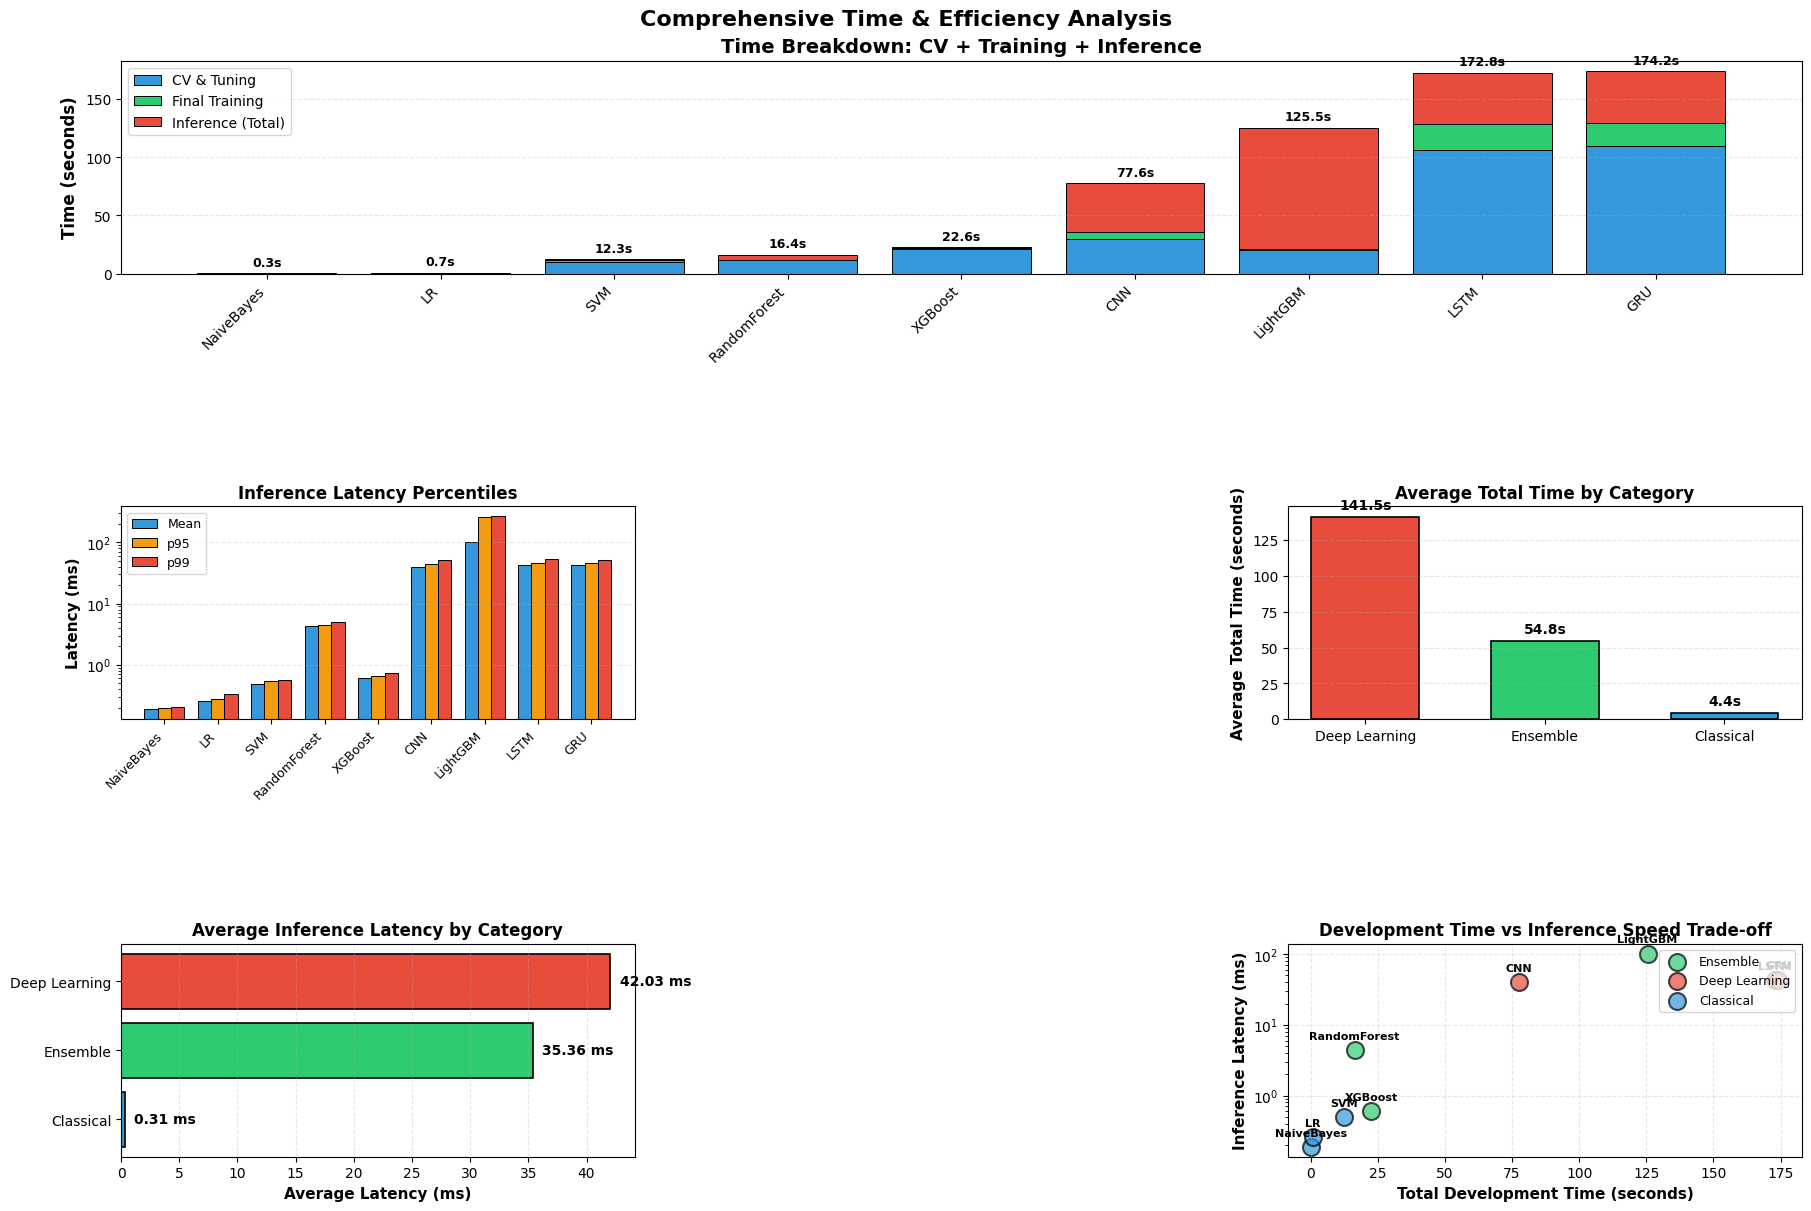


✓ Time analysis visualizations generated successfully!


In [75]:
# ====================================================================================
# HÜCRE 8: COMPREHENSIVE TIME ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("COMPREHENSIVE TIME & EFFICIENCY ANALYSIS")
print("=" * 120)

# Prepare data from model_results
timing_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "CV Time (s)": metrics.get("CV_Time", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0),
        "Total Time (s)": metrics.get("Total_Time", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0)
    }
    timing_data.append(row)

# Create DataFrame
df_time = pd.DataFrame(timing_data)

# Sort by Total Time
df_time = df_time.sort_values("Total Time (s)", ascending=True).reset_index(drop=True)

# Display table
print("\n📊 DETAILED TIME BREAKDOWN:")
print("-" * 120)
print(df_time.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 TIME STATISTICS:")
print(f"   Fastest Total:     {df_time.iloc[0]['Model']:<15} ({df_time.iloc[0]['Total Time (s)']:.2f} s)")
print(f"   Slowest Total:     {df_time.iloc[-1]['Model']:<15} ({df_time.iloc[-1]['Total Time (s)']:.2f} s)")
print(f"   Fastest Inference: {df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")
print(f"   Slowest Inference: {df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Stacked Time Breakdown (CV + Training + Inference)
ax1 = fig.add_subplot(gs[0, :])
models = df_time['Model'].values
cv_times = df_time['CV Time (s)'].values
train_times = df_time['Training Time (s)'].values
inf_times = df_time['Inference Time (s)'].values

x_pos = np.arange(len(models))
p1 = ax1.bar(x_pos, cv_times, label='CV & Tuning', color='#3498db', edgecolor='black', linewidth=0.7)
p2 = ax1.bar(x_pos, train_times, bottom=cv_times, label='Final Training', 
             color='#2ecc71', edgecolor='black', linewidth=0.7)
p3 = ax1.bar(x_pos, inf_times, bottom=cv_times+train_times, label='Inference (Total)', 
             color='#e74c3c', edgecolor='black', linewidth=0.7)

ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Time Breakdown: CV + Training + Inference', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add total time labels on top
for i, (cv, tr, inf) in enumerate(zip(cv_times, train_times, inf_times)):
    total = cv + tr + inf
    ax1.text(i, total + max(cv_times+train_times+inf_times)*0.02, f'{total:.1f}s', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Latency Percentiles Comparison
ax2 = fig.add_subplot(gs[1, 0])
lat_mean = df_time['Latency Mean (ms)'].values
lat_p95 = df_time['Latency p95 (ms)'].values
lat_p99 = df_time['Latency p99 (ms)'].values

x_pos2 = np.arange(len(models))
width = 0.25

bars1 = ax2.bar(x_pos2 - width, lat_mean, width, label='Mean', 
                color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax2.bar(x_pos2, lat_p95, width, label='p95', 
                color='#f39c12', edgecolor='black', linewidth=0.7)
bars3 = ax2.bar(x_pos2 + width, lat_p99, width, label='p99', 
                color='#e74c3c', edgecolor='black', linewidth=0.7)

ax2.set_ylabel('Latency (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Inference Latency Percentiles', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_yscale('log')  # Log scale for better visibility
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 3: Category-wise Total Time Comparison
ax3 = fig.add_subplot(gs[1, 1])
category_time = df_time.groupby('Category')['Total Time (s)'].mean().sort_values(ascending=False)
colors_cat = [category_colors.get(cat, '#95a5a6') for cat in category_time.index]

bars_cat = ax3.bar(category_time.index, category_time.values, color=colors_cat,
                   edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average Total Time (seconds)', fontsize=11, fontweight='bold')
ax3.set_title('Average Total Time by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_time.values):
    ax3.text(i, v + max(category_time.values)*0.02, f'{v:.1f}s', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Category-wise Inference Latency
ax4 = fig.add_subplot(gs[2, 0])
category_latency = df_time.groupby('Category')['Latency Mean (ms)'].mean().sort_values(ascending=True)
colors_cat2 = [category_colors.get(cat, '#95a5a6') for cat in category_latency.index]

bars_lat = ax4.barh(category_latency.index, category_latency.values, color=colors_cat2,
                    edgecolor='black', linewidth=1.2)
ax4.set_xlabel('Average Latency (ms)', fontsize=11, fontweight='bold')
ax4.set_title('Average Inference Latency by Category', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_latency.values):
    ax4.text(v + max(category_latency.values)*0.02, i, f'{v:.2f} ms', 
            va='center', fontsize=10, fontweight='bold')

# Panel 5: Efficiency Matrix (Time vs Latency)
ax5 = fig.add_subplot(gs[2, 1])
for category in set(df_time['Category']):
    mask = df_time['Category'] == category
    ax5.scatter(df_time[mask]['Total Time (s)'], 
               df_time[mask]['Latency Mean (ms)'],
               s=150, alpha=0.7, 
               color=category_colors.get(category, '#95a5a6'),
               edgecolors='black', linewidth=1.5, 
               label=category)
    
    # Add labels
    for _, row in df_time[mask].iterrows():
        ax5.annotate(row['Model'], 
                    (row['Total Time (s)'], row['Latency Mean (ms)']),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8, fontweight='bold')

ax5.set_xlabel('Total Development Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Inference Latency (ms)', fontsize=11, fontweight='bold')
ax5.set_title('Development Time vs Inference Speed Trade-off', fontsize=12, fontweight='bold')
ax5.set_yscale('log')
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Comprehensive Time & Efficiency Analysis', fontsize=16, fontweight='bold')
plt.savefig('comprehensive_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Time analysis visualizations generated successfully!")
print("=" * 120)

### 9. Overfitting Analysis


OVERFITTING & GENERALIZATION ANALYSIS

📊 GENERALIZATION PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  Train Accuracy  Test Accuracy  Gen. Gap (Acc)  Train MCC  Test MCC  Gen. Gap (MCC)  CV Accuracy Mean  CV Accuracy Std  CV MCC Mean  CV MCC Std Risk Level
RandomForest      Ensemble          0.9826         0.9778          0.0048     0.9196    0.8980          0.0216            0.9799           0.0041       0.9070      0.0192      ✅ LOW
         GRU Deep Learning          0.9894         0.9807          0.0087     0.9511    0.9103          0.0408            0.9797           0.0050       0.9089      0.0189      ✅ LOW
     XGBoost      Ensemble          0.9918         0.9807          0.0111     0.9624    0.9121          0.0504            0.9780           0.0027       0.8989      0.0130      ✅ LOW
        LSTM Deep Learning          0.9964         0.9845          0.0118     0.9

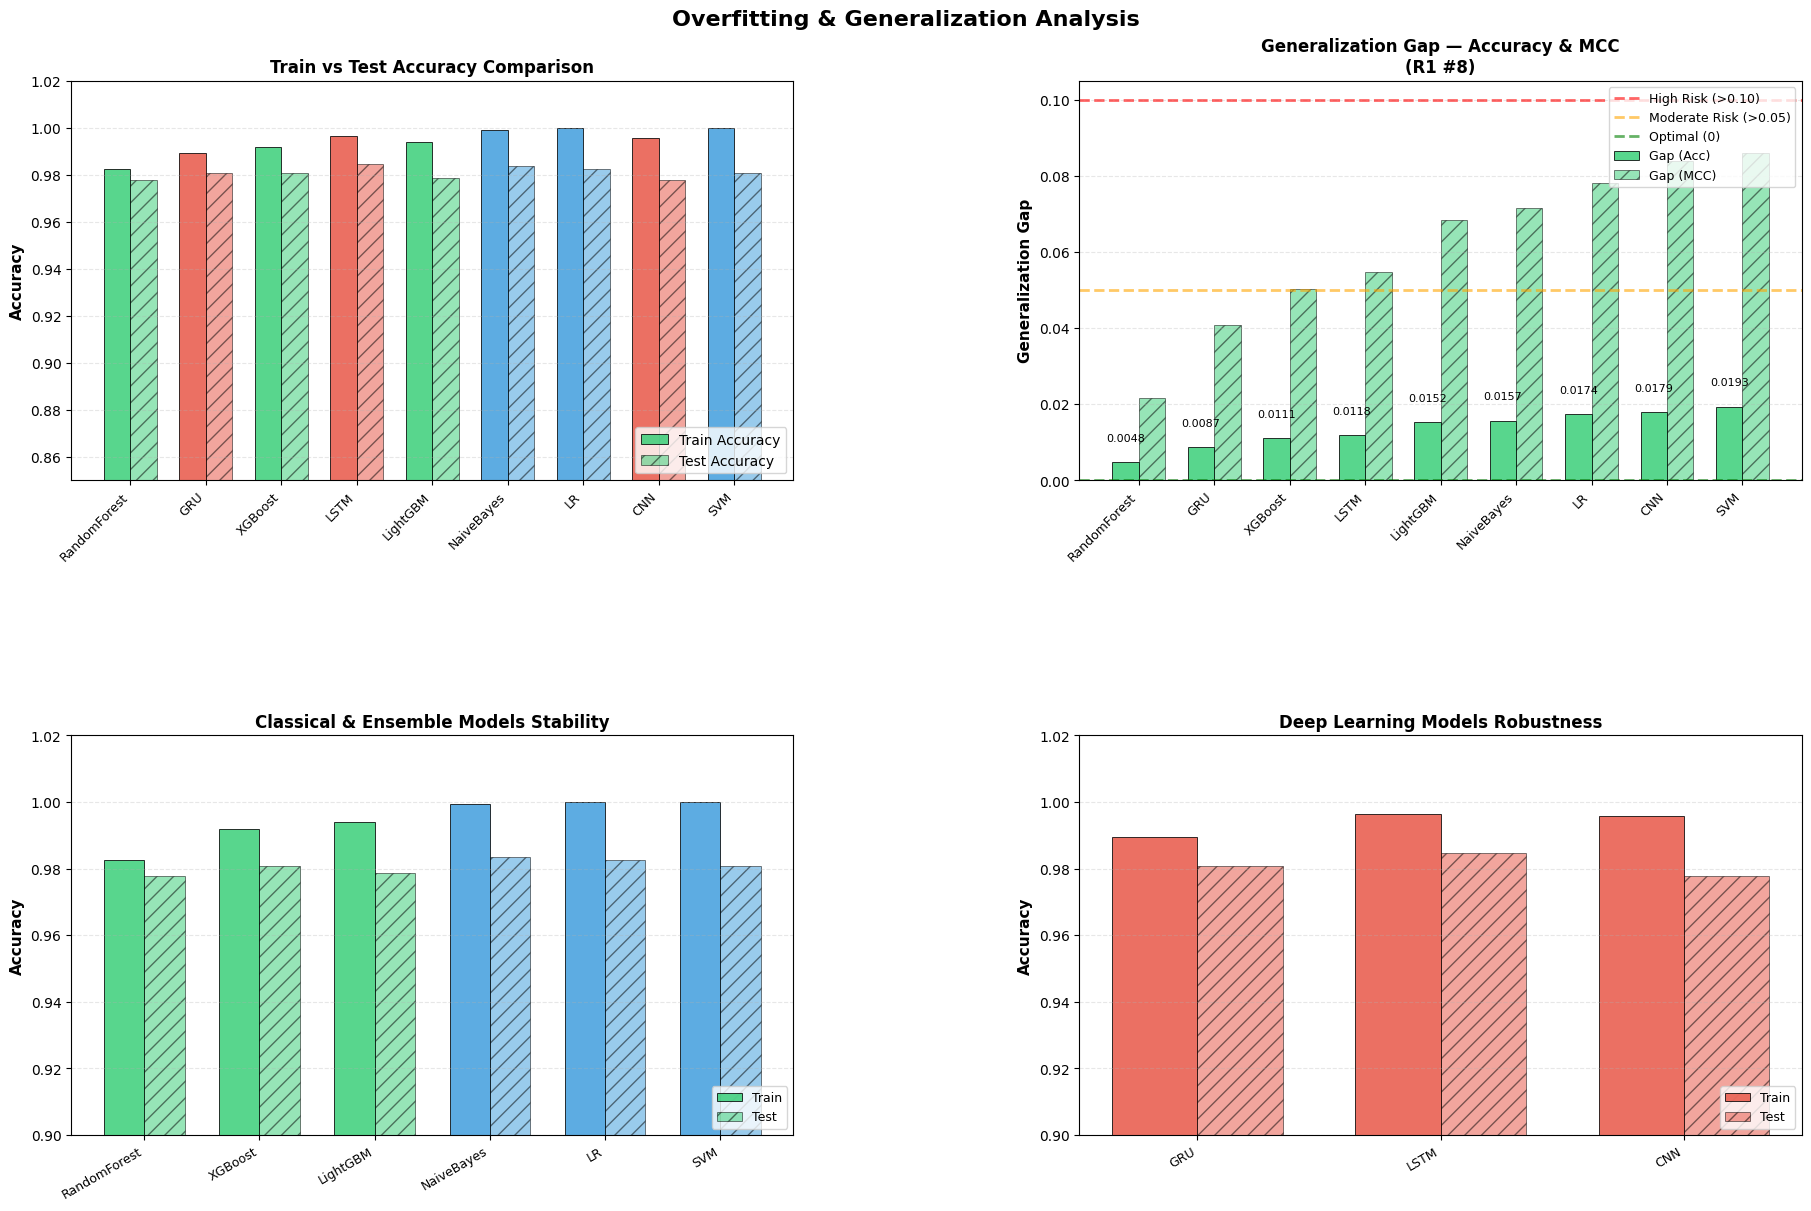


✓ Overfitting analysis visualizations generated successfully!


In [76]:
# ====================================================================================
# HÜCRE 9: OVERFITTING & GENERALIZATION ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("OVERFITTING & GENERALIZATION ANALYSIS")
print("=" * 120)

# Prepare data from model_results
overfitting_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":              model_name,
        "Category":           metrics.get("Category", "Unknown"),
        "Train Accuracy":     metrics.get("Train_Accuracy", 0),
        "Test Accuracy":      metrics.get("Test_Accuracy", 0),
        # FIX: key renamed to Generalization_Gap_Acc (R1 #8)
        "Gen. Gap (Acc)":     metrics.get("Generalization_Gap_Acc", 0),
        # NEW: MCC-based gap (R1 #8)
        "Train MCC":          metrics.get("Train_MCC", 0),
        "Test MCC":           metrics.get("Test_MCC", 0),
        "Gen. Gap (MCC)":     metrics.get("Generalization_Gap_MCC", 0),
        "CV Accuracy Mean":   metrics.get("CV_Accuracy_Mean", 0),
        "CV Accuracy Std":    metrics.get("CV_Accuracy_Std", 0),
        "CV MCC Mean":        metrics.get("CV_MCC_Mean", 0),
        "CV MCC Std":         metrics.get("CV_MCC_Std", 0),
    }
    overfitting_data.append(row)

df_overfit = pd.DataFrame(overfitting_data)

# Sort by Generalization Gap Acc (ascending - lower is better)
df_overfit = df_overfit.sort_values("Gen. Gap (Acc)", ascending=True).reset_index(drop=True)

# Risk classification — based on accuracy gap
df_overfit['Risk Level'] = df_overfit['Gen. Gap (Acc)'].apply(
    lambda x: "🚨 HIGH" if x > 0.10 else ("⚠️ MODERATE" if x > 0.05 else "✅ LOW")
)

# Display table
print("\n📊 GENERALIZATION PERFORMANCE:")
print("-" * 120)
print(df_overfit.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 OVERFITTING STATISTICS:")
print(f"   Best Generalization:  {df_overfit.iloc[0]['Model']:<15} "
      f"(Gap Acc: {df_overfit.iloc[0]['Gen. Gap (Acc)']:.4f} | "
      f"Gap MCC: {df_overfit.iloc[0]['Gen. Gap (MCC)']:.4f})")
print(f"   Worst Generalization: {df_overfit.iloc[-1]['Model']:<15} "
      f"(Gap Acc: {df_overfit.iloc[-1]['Gen. Gap (Acc)']:.4f} | "
      f"Gap MCC: {df_overfit.iloc[-1]['Gen. Gap (MCC)']:.4f})")
print(f"   Average Gap (Acc):    {df_overfit['Gen. Gap (Acc)'].mean():.4f}")
print(f"   Average Gap (MCC):    {df_overfit['Gen. Gap (MCC)'].mean():.4f}")
print(f"   High Risk Models:     {len(df_overfit[df_overfit['Gen. Gap (Acc)'] > 0.10])}")
print(f"   Low Risk Models:      {len(df_overfit[df_overfit['Gen. Gap (Acc)'] <= 0.05])}")

# Category-wise summary
print("\n📊 CATEGORY-WISE GENERALIZATION:")
category_summary = df_overfit.groupby('Category').agg({
    'Gen. Gap (Acc)': ['mean', 'std', 'min', 'max'],
    'Gen. Gap (MCC)': ['mean', 'std', 'min', 'max'],
}).round(4)
print(category_summary)

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs  = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

category_colors = {
    'Classical':     '#3498db',
    'Ensemble':      '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Train vs Test Accuracy
ax1   = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(df_overfit))
width = 0.35

colors_cat = [category_colors.get(cat, '#95a5a6') for cat in df_overfit['Category']]

ax1.bar(x_pos - width/2, df_overfit['Train Accuracy'], width,
        label='Train Accuracy', color=colors_cat, alpha=0.8,
        edgecolor='black', linewidth=0.7)
ax1.bar(x_pos + width/2, df_overfit['Test Accuracy'], width,
        label='Test Accuracy', color=colors_cat, alpha=0.5,
        edgecolor='black', linewidth=0.7, hatch='//')

ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Train vs Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.85, 1.02])

# Panel 2: Generalization Gap Acc + MCC side by side
ax2 = fig.add_subplot(gs[0, 1])
gap_colors = ['#e74c3c' if g > 0.10 else '#f39c12' if g > 0.05 else '#2ecc71'
              for g in df_overfit['Gen. Gap (Acc)']]

x_pos2 = np.arange(len(df_overfit))
ax2.bar(x_pos2 - width/2, df_overfit['Gen. Gap (Acc)'], width,
        color=gap_colors, edgecolor='black', linewidth=0.7, alpha=0.8, label='Gap (Acc)')
ax2.bar(x_pos2 + width/2, df_overfit['Gen. Gap (MCC)'], width,
        color=gap_colors, edgecolor='black', linewidth=0.7, alpha=0.5,
        hatch='//', label='Gap (MCC)')

ax2.set_ylabel('Generalization Gap', fontsize=11, fontweight='bold')
ax2.set_title('Generalization Gap — Accuracy & MCC\n(R1 #8)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)
ax2.axhline(y=0.10, color='red',    linestyle='--', linewidth=2, alpha=0.6, label='High Risk (>0.10)')
ax2.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, alpha=0.6, label='Moderate Risk (>0.05)')
ax2.axhline(y=0.00, color='green',  linestyle='--', linewidth=2, alpha=0.6, label='Optimal (0)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(df_overfit['Gen. Gap (Acc)']):
    ax2.text(i - width/2, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# Panel 3: Classical & Ensemble stability
ax3 = fig.add_subplot(gs[1, 0])
df_ce = df_overfit[df_overfit['Category'].isin(['Classical', 'Ensemble'])]

if not df_ce.empty:
    x_ce     = np.arange(len(df_ce))
    colors_ce = [category_colors.get(cat, '#95a5a6') for cat in df_ce['Category']]

    ax3.bar(x_ce - width/2, df_ce['Train Accuracy'], width,
            label='Train', color=colors_ce, alpha=0.8, edgecolor='black', linewidth=0.7)
    ax3.bar(x_ce + width/2, df_ce['Test Accuracy'], width,
            label='Test',  color=colors_ce, alpha=0.5, edgecolor='black',
            linewidth=0.7, hatch='//')

    ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax3.set_title('Classical & Ensemble Models Stability', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_ce)
    ax3.set_xticklabels(df_ce['Model'], rotation=30, ha='right', fontsize=9)
    ax3.legend(loc='lower right', fontsize=9)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.set_ylim([0.90, 1.02])

# Panel 4: Deep Learning robustness
ax4 = fig.add_subplot(gs[1, 1])
df_dl = df_overfit[df_overfit['Category'] == 'Deep Learning']

if not df_dl.empty:
    x_dl     = np.arange(len(df_dl))
    color_dl = category_colors.get('Deep Learning', '#e74c3c')

    ax4.bar(x_dl - width/2, df_dl['Train Accuracy'], width,
            label='Train', color=color_dl, alpha=0.8, edgecolor='black', linewidth=0.7)
    ax4.bar(x_dl + width/2, df_dl['Test Accuracy'], width,
            label='Test',  color=color_dl, alpha=0.5, edgecolor='black',
            linewidth=0.7, hatch='//')

    ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax4.set_title('Deep Learning Models Robustness', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_dl)
    ax4.set_xticklabels(df_dl['Model'], rotation=30, ha='right', fontsize=9)
    ax4.legend(loc='lower right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.set_ylim([0.90, 1.02])

plt.suptitle('Overfitting & Generalization Analysis', fontsize=16, fontweight='bold')
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Overfitting analysis visualizations generated successfully!")
print("=" * 120)

### 10. ALL CONFUSION MATRICES

 DistilBERT skipped (Not trained yet).

 Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'


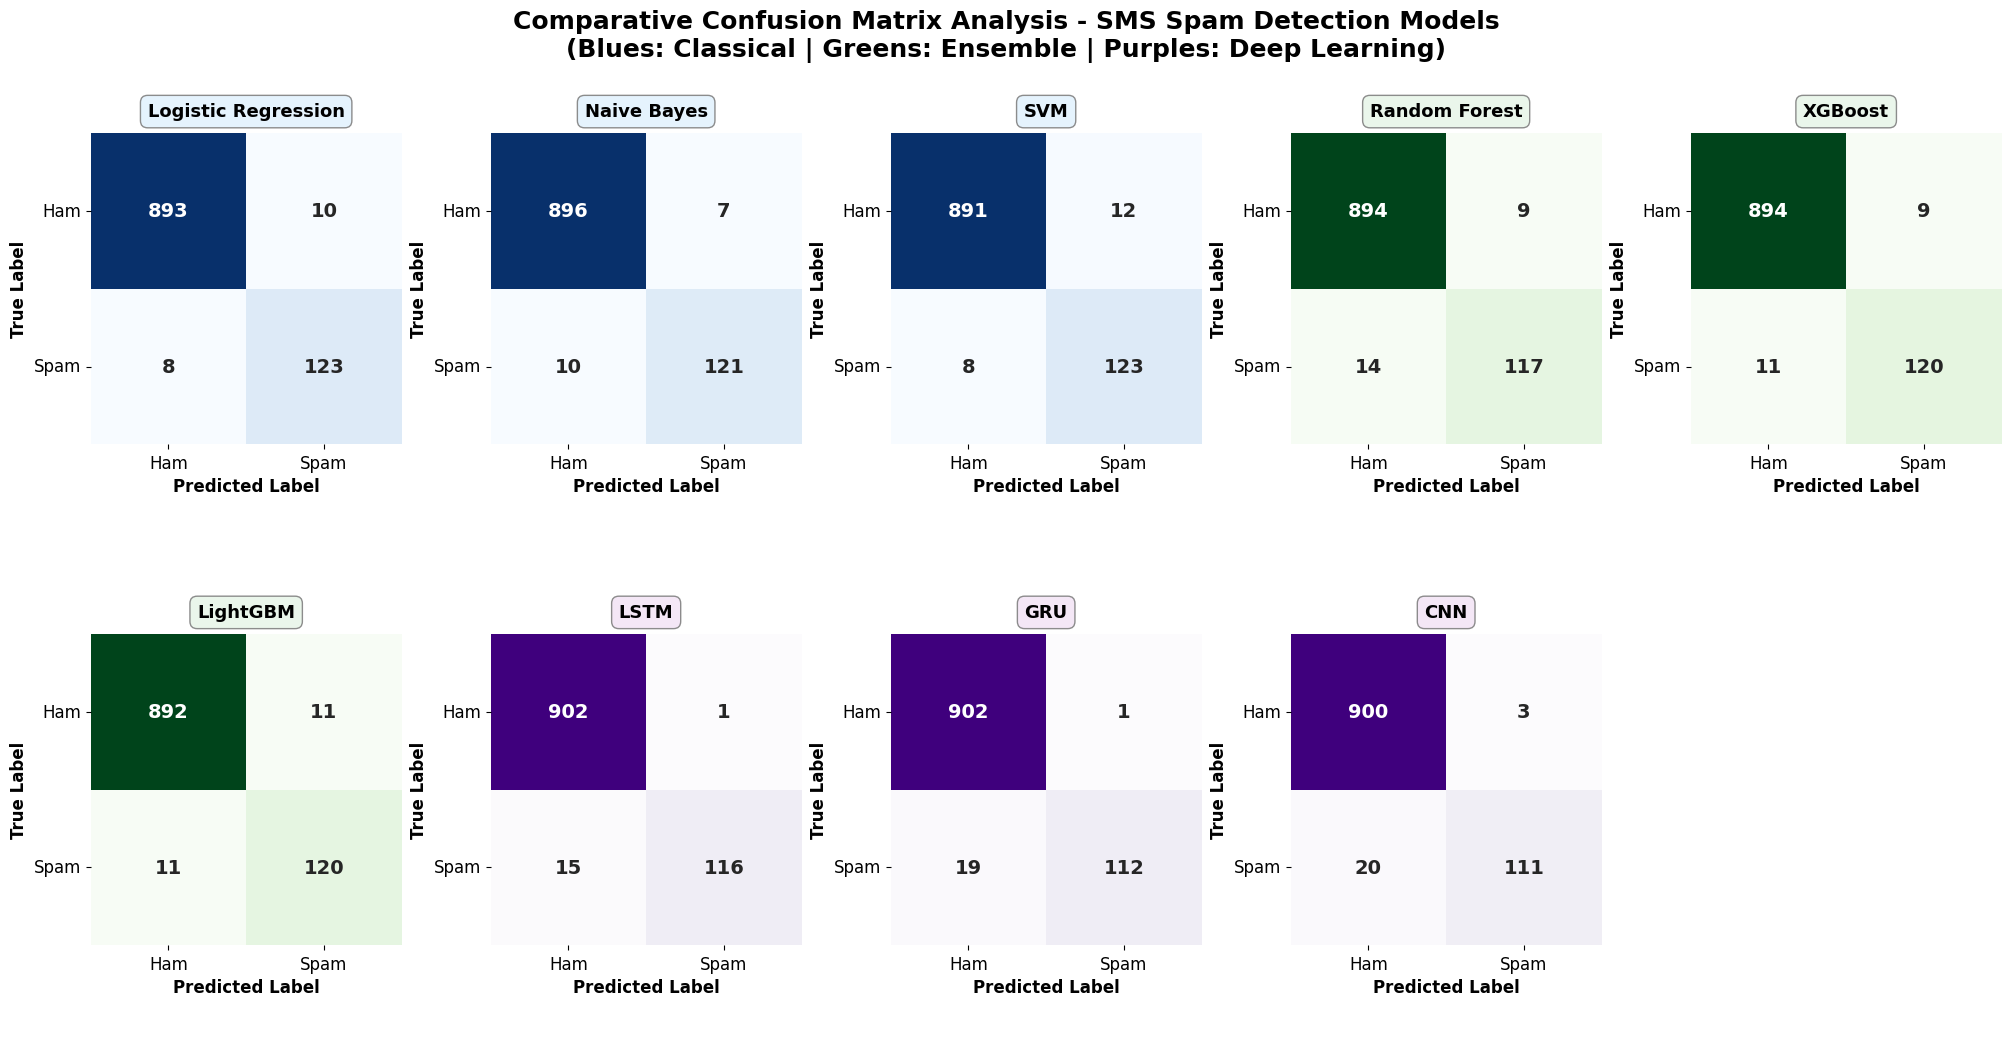

In [77]:
# =============================================================================
# CELL 18: ALL CONFUSION MATRICES - CATEGORIZED BY COLOR (FINAL 10 MODELS)
# =============================================================================

# 1. Memory Cleanup and Layout Settings
plt.close('all')

# 2. Define Final 10 Models (Mapped to SMS Spam Project Variables)
model_map_config = [
    # Classical (Blue)
    ("Logistic Regression", "best_lr_predict",  "Classical"),
    ("Naive Bayes",         "best_nb_predict",  "Classical"),
    ("SVM",                 "best_svm_predict", "Classical"),
    
    # Ensemble (Green)
    ("Random Forest",       "best_rf_predict",  "Ensemble"),
    ("XGBoost",             "best_xgb_predict", "Ensemble"),
    ("LightGBM",            "best_lgbm_predict", "Ensemble"),
 
    # Deep Learning (Purple)
    ("LSTM",                "best_lstm_predict", "Deep Learning"),
    ("GRU",                 "best_gru_predict",  "Deep Learning"),
    ("CNN",                 "best_cnn_predict",  "Deep Learning"),
    ("DistilBERT",          "best_bert_predict", "Deep Learning")
]

# Check for active models in memory to avoid errors
active_models = []
for name, var_name, category in model_map_config:
    if var_name in globals():
        active_models.append((name, globals()[var_name], category))
    else:
        print(f" {name} skipped (Not trained yet).")

if not active_models:
    print(" ERROR: No model results found in memory.")
else:
    # 3. Dynamic Grid Setup
    num_models = len(active_models)
    cols = 5  # Optimized for 10 models (2 Rows x 5 Columns)
    rows = (num_models // cols) + (1 if num_models % cols > 0 else 0)
    
    # Adjusted figsize to match the template's proportions
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), layout='constrained')
    axes = axes.ravel() 
    
    # 4. Color Palettes and Themes (Template Style)
    category_colors = {
        'Classical': 'Blues',
        'Ensemble': 'Greens', 
        'Deep Learning': 'Purples' # Template requested Purples
    }
    
    background_colors = {
        'Classical': '#E3F2FD', 
        'Ensemble': '#E8F5E9', 
        'Deep Learning': '#F3E5F5'
    }

    # 5. Drawing Loop
    for idx, (name, pred, category) in enumerate(active_models):
        y_true = y_test 
        
        # Flatten deep learning predictions if necessary
        if hasattr(pred, "ndim") and pred.ndim > 1: 
            pred = pred.flatten()
        
        cm = confusion_matrix(y_true, pred)
        
        # Heatmap plotting (Template styling)
        sns.heatmap(cm, annot=True, fmt='d', cmap=category_colors[category], 
                    ax=axes[idx], cbar=False, square=True, 
                    annot_kws={'size': 14, 'weight': 'bold'}) # Font size 14 as per template style
        
        # Title and Header Style (Rounded Box)
        axes[idx].set_title(f'{name}', 
                            fontsize=13, fontweight='bold', pad=12,
                            bbox=dict(boxstyle='round,pad=0.4', 
                                      facecolor=background_colors[category],
                                      edgecolor='gray',
                                      alpha=0.9))
                                      
        axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
        
        # Labels: Ham vs Spam
        axes[idx].set_xticklabels(['Ham', 'Spam'], fontsize=12)
        axes[idx].set_yticklabels(['Ham', 'Spam'], fontsize=12, rotation=0)

    # 6. Hide empty subplots
    for i in range(num_models, len(axes)):
        axes[i].axis('off')

    # 7. Final Suptitle and Save
    plt.suptitle('Comparative Confusion Matrix Analysis - SMS Spam Detection Models\n(Blues: Classical | Greens: Ensemble | Purples: Deep Learning)', 
                 fontsize=18, fontweight='bold', y=1.03)

    try:
        plt.savefig('confusion_matrices_final_styled.png', dpi=300, bbox_inches='tight')
        print("\n Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'")
    except Exception as e:
        print(f"\n Save failed: {e}")

    plt.show()

## 11. Comprehensive Performance Heatmap


GENERATING COMPREHENSIVE PERFORMANCE HEATMAP
✓ Heatmap saved as 'comprehensive_performance_heatmap.png'


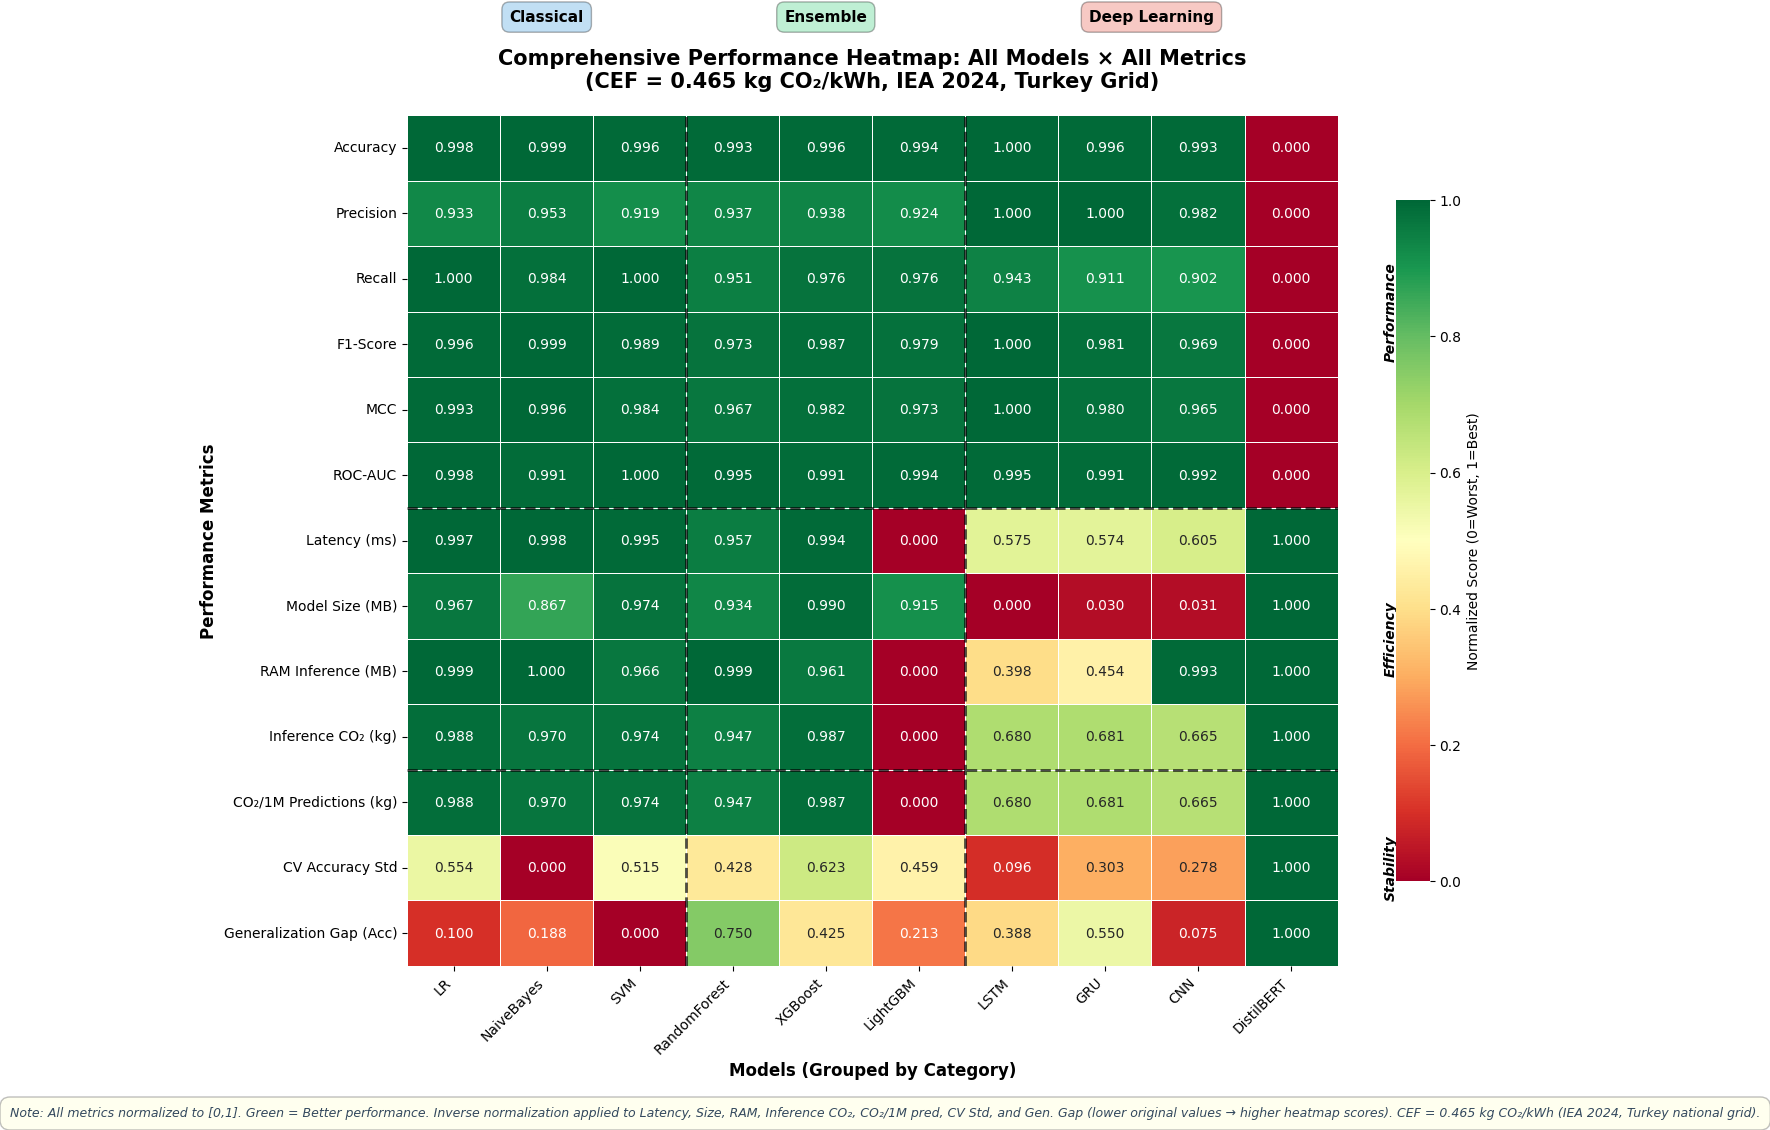


📊 HEATMAP STATISTICAL SUMMARY:
------------------------------------------------------------------------------------------------------------------------

🏆 OVERALL BEST MODEL (Highest Avg Normalized Score):
   XGBoost: 0.9106

📈 TOP 5 MODELS (by average normalized score):
   1. XGBoost         0.9106  (Ensemble)
   2. RandomForest    0.9060  (Ensemble)
   3. LR              0.8853  (Classical)
   4. SVM             0.8680  (Classical)
   5. NaiveBayes      0.8395  (Classical)

🎯 BEST PERFORMERS BY METRIC:
------------------------------------------------------------------------------------------------------------------------
   Accuracy                       → LSTM            (score: 1.0000)
   Precision                      → LSTM            (score: 1.0000)
   Recall                         → LR              (score: 1.0000)
   F1-Score                       → LSTM            (score: 1.0000)
   MCC                            → LSTM            (score: 1.0000)
   ROC-AUC                  

In [82]:
# ====================================================================================
# HÜCRE 11: COMPREHENSIVE PERFORMANCE HEATMAP (13 Metrics × 10 Models)
# ====================================================================================

print("\n" + "=" * 120)
print("GENERATING COMPREHENSIVE PERFORMANCE HEATMAP")
print("=" * 120)

plt.close('all')

# ================================================================================
# 1. DEFINE STRUCTURE
# ================================================================================

results_df = pd.DataFrame.from_dict(model_results, orient='index')

# Metrics (rows) — 13 comprehensive metrics
metrics_list = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "MCC",
    "ROC_AUC",
    "Latency_ms",
    "Model_Size_MB",
    "RAM_Inference_MB",
    "Inference_CO2_kg",         # FIX: was CO2_emissions_kg
    "CO2_per_1M_pred_kg",       # NEW: R1 #9 — scalability metric
    "CV_Accuracy_Std",
    "Generalization_Gap_Acc",   # FIX: was Generalization_Gap
]

# Display names for metrics
metrics_display = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "MCC",
    "ROC-AUC",
    "Latency (ms)",
    "Model Size (MB)",
    "RAM Inference (MB)",
    "Inference CO₂ (kg)",       # FIX
    "CO₂/1M Predictions (kg)",  # NEW
    "CV Accuracy Std",
    "Generalization Gap (Acc)", # FIX
]

# Models (columns) — sorted by category
models_list = [
    # Classical
    "LR", "NaiveBayes", "SVM",
    # Ensemble
    "RandomForest", "XGBoost", "LightGBM",
    # Deep Learning
    "LSTM", "GRU", "CNN", "DistilBERT"
]

# ================================================================================
# 2. COLLECT RAW DATA
# ================================================================================

all_values = {metric: [] for metric in metrics_list}

for model_name in models_list:
    if model_name in model_results:
        for metric in metrics_list:
            value = results_df.loc[model_name, metric] if model_name in results_df.index and metric in results_df.columns else 0
            all_values[metric].append(value)

# ================================================================================
# 3. NORMALIZATION FUNCTION
# ================================================================================

def normalize_to_01(values, inverse=False):
    """
    Normalize list of values to [0, 1] range.
    inverse=True: lower original values become higher normalized scores (lower is better).
    """
    values = np.array(values, dtype=float)
    if len(values) == 0:
        return values
    if np.max(values) == np.min(values):
        return np.full_like(values, 0.5)
    normalized = (values - np.min(values)) / (np.max(values) - np.min(values))
    if inverse:
        normalized = 1 - normalized
    return normalized

# Metrics where lower original value = better performance
inverse_metrics = [
    "Latency_ms",
    "Model_Size_MB",
    "RAM_Inference_MB",
    "Inference_CO2_kg",       # FIX
    "CO2_per_1M_pred_kg",     # NEW
    "CV_Accuracy_Std",
    "Generalization_Gap_Acc", # FIX
]

# ================================================================================
# 4. BUILD NORMALIZED HEATMAP MATRIX
# ================================================================================

heatmap_data = []

for metric in metrics_list:
    raw_values = []
    for model_name in models_list:
        if model_name in model_results:
            raw_values.append(results_df.loc[model_name, metric] if model_name in results_df.index and metric in results_df.columns else 0)
        else:
            raw_values.append(0)

    is_inverse = metric in inverse_metrics
    normalized = normalize_to_01(raw_values, inverse=is_inverse)
    heatmap_data.append(normalized)

df_heatmap = pd.DataFrame(
    heatmap_data,
    index=metrics_display,
    columns=models_list
)

# ================================================================================
# 5. CREATE HEATMAP
# ================================================================================

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    df_heatmap,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    center=0.5,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'Normalized Score (0=Worst, 1=Best)',
        'shrink': 0.8
    },
    ax=ax
)

# ================================================================================
# 6. FORMATTING & ANNOTATIONS
# ================================================================================

ax.set_title(
    'Comprehensive Performance Heatmap: All Models × All Metrics\n'
    '(CEF = 0.465 kg CO₂/kWh, IEA 2024, Turkey Grid)',
    fontsize=15, fontweight='bold', pad=20
)

ax.set_xlabel('Models (Grouped by Category)', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance Metrics', fontsize=12, fontweight='bold')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)

# Vertical category separators
for boundary in [3, 6]:
    ax.axvline(x=boundary, color='black', linewidth=2, linestyle='--', alpha=0.7)

# Category labels at top
category_positions = [1.5, 4.5, 8]
category_labels    = ['Classical', 'Ensemble', 'Deep Learning']
category_colors_bg = ['#3498db', '#2ecc71', '#e74c3c']

for pos, label, color in zip(category_positions, category_labels, category_colors_bg):
    ax.text(pos, -1.5, label,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.3, edgecolor='black'))

# Horizontal metric group separators
# Performance: 0-6, Efficiency: 6-10, Stability: 10-13
for boundary in [6, 10]:
    ax.axhline(y=boundary, color='black', linewidth=2, linestyle='--', alpha=0.7)

# Metric group labels on the right
metric_group_positions = [3, 8, 11.5]
metric_group_labels    = ['Performance', 'Efficiency', 'Stability']

for pos, label in zip(metric_group_positions, metric_group_labels):
    ax.text(len(models_list) + 0.5, pos, label,
            ha='left', va='center',
            fontsize=10, fontweight='bold', style='italic',
            rotation=90)

# ================================================================================
# 7. EXPLANATORY NOTE
# ================================================================================

fig.text(
    0.5, -0.02,
    'Note: All metrics normalized to [0,1]. Green = Better performance. '
    'Inverse normalization applied to Latency, Size, RAM, Inference CO₂, CO₂/1M pred, '
    'CV Std, and Gen. Gap (lower original values → higher heatmap scores). '
    'CEF = 0.465 kg CO₂/kWh (IEA 2024, Turkey national grid).',
    ha='center', fontsize=9, style='italic', color='#34495e',
    bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', alpha=0.5, edgecolor='gray')
)

# ================================================================================
# 8. SAVE & DISPLAY
# ================================================================================

plt.tight_layout()
plt.savefig('comprehensive_performance_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Heatmap saved as 'comprehensive_performance_heatmap.png'")
plt.show()

# ================================================================================
# 9. STATISTICAL SUMMARY
# ================================================================================

print("\n📊 HEATMAP STATISTICAL SUMMARY:")
print("-" * 120)

model_averages = df_heatmap.mean(axis=0).sort_values(ascending=False)
print(f"\n🏆 OVERALL BEST MODEL (Highest Avg Normalized Score):")
print(f"   {model_averages.index[0]}: {model_averages.values[0]:.4f}")

print(f"\n📈 TOP 5 MODELS (by average normalized score):")
for i, (model, score) in enumerate(model_averages.head(5).items(), 1):
    category = "Classical"     if model in ["LR", "NaiveBayes", "SVM"] else \
               "Ensemble"      if model in ["RandomForest", "XGBoost", "LightGBM"] else \
               "Deep Learning"
    print(f"   {i}. {model:<15} {score:.4f}  ({category})")

print(f"\n🎯 BEST PERFORMERS BY METRIC:")
print("-" * 120)
for metric_display, metric_data in zip(metrics_display, df_heatmap.values):
    best_model_idx = np.argmax(metric_data)
    best_model     = models_list[best_model_idx]
    best_score     = metric_data[best_model_idx]
    print(f"   {metric_display:<30} → {best_model:<15} (score: {best_score:.4f})")

print(f"\n📊 CATEGORY-WISE AVERAGE NORMALIZED SCORES:")
print("-" * 120)

classical_models = ["LR", "NaiveBayes", "SVM"]
ensemble_models  = ["RandomForest", "XGBoost", "LightGBM"]
dl_models        = ["LSTM", "GRU", "CNN", "DistilBERT"]

classical_avg = df_heatmap[[m for m in classical_models if m in df_heatmap.columns]].mean().mean()
ensemble_avg  = df_heatmap[[m for m in ensemble_models  if m in df_heatmap.columns]].mean().mean()
dl_avg        = df_heatmap[[m for m in dl_models        if m in df_heatmap.columns]].mean().mean()

print(f"   Classical ML:        {classical_avg:.4f}")
print(f"   Ensemble Learning:   {ensemble_avg:.4f}")
print(f"   Deep Learning:       {dl_avg:.4f}")

print("\n" + "=" * 120)


GENERATING COMPREHENSIVE PERFORMANCE HEATMAPS

📋 Model Order (by Category):
   Classical: LR, NaiveBayes, SVM
   Ensemble: LightGBM, RandomForest, XGBoost
   Deep Learning: CNN, GRU, LSTM

📊 Creating Performance Heatmap...


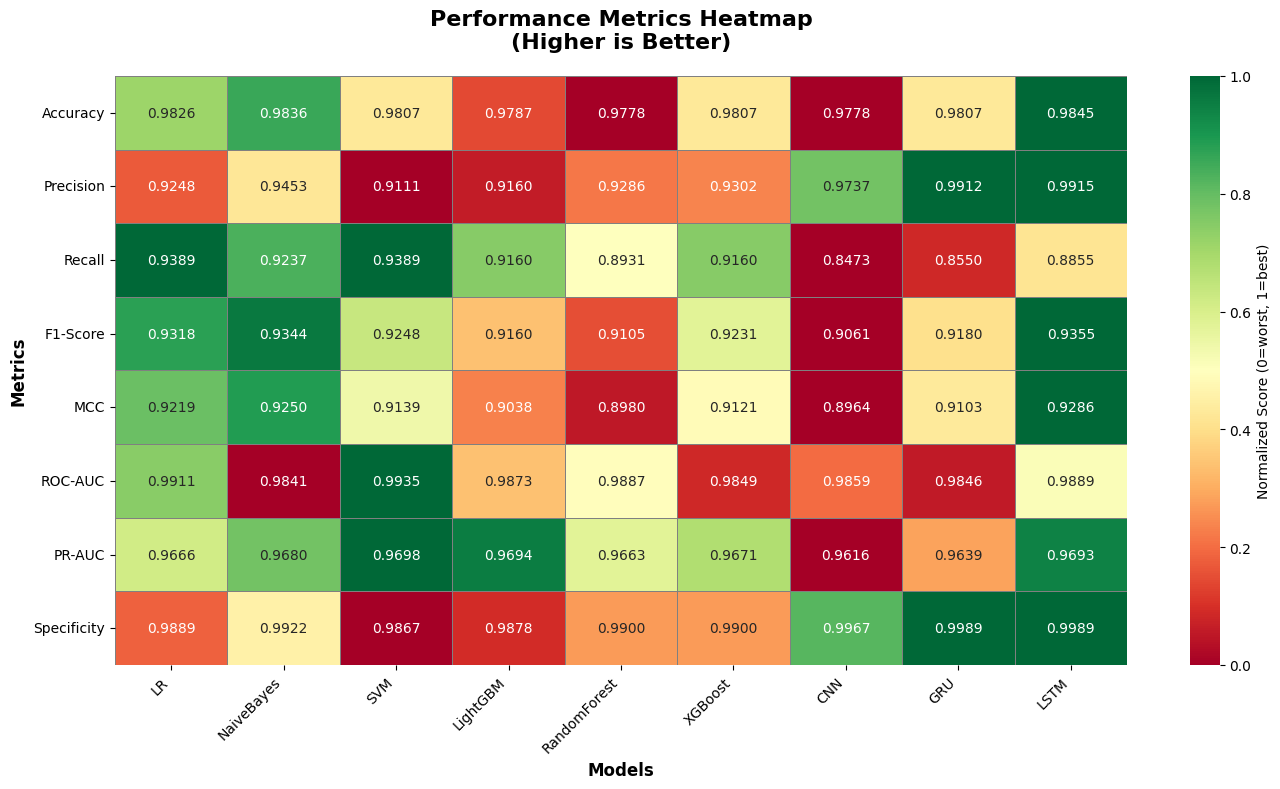

✓ Performance Heatmap completed

⚡ Creating Efficiency Heatmap...


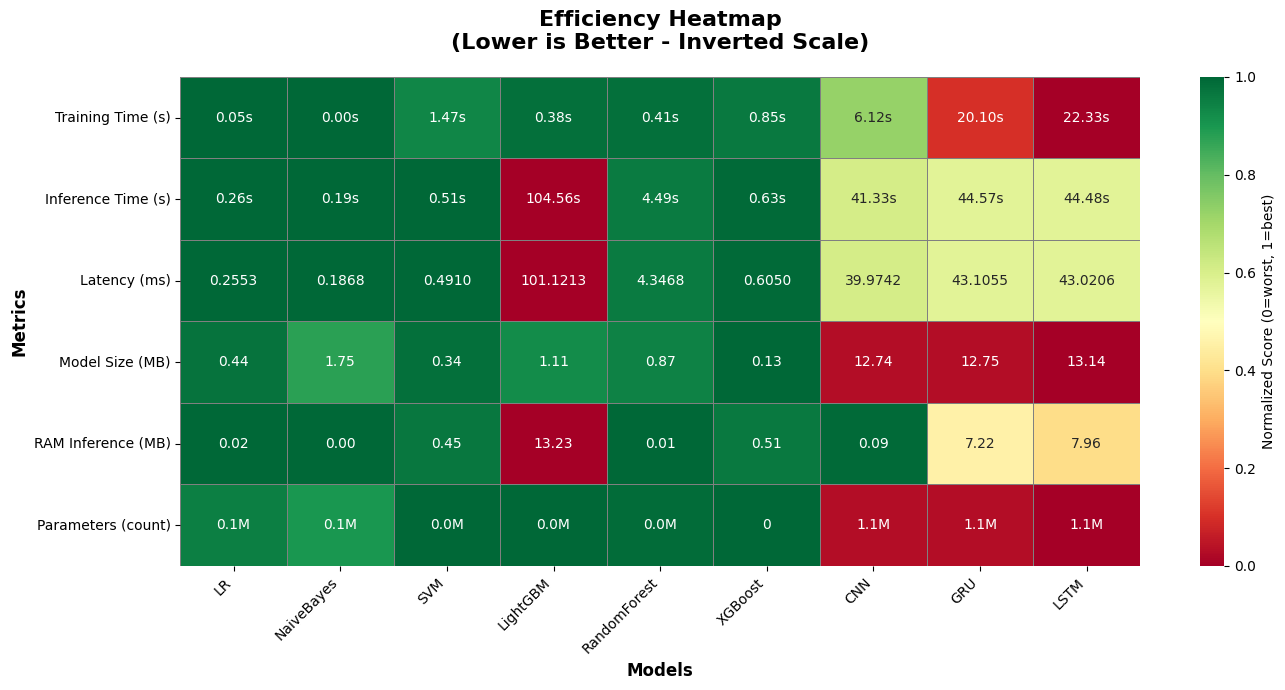

✓ Efficiency Heatmap completed

🌱 Creating Sustainability Heatmap...


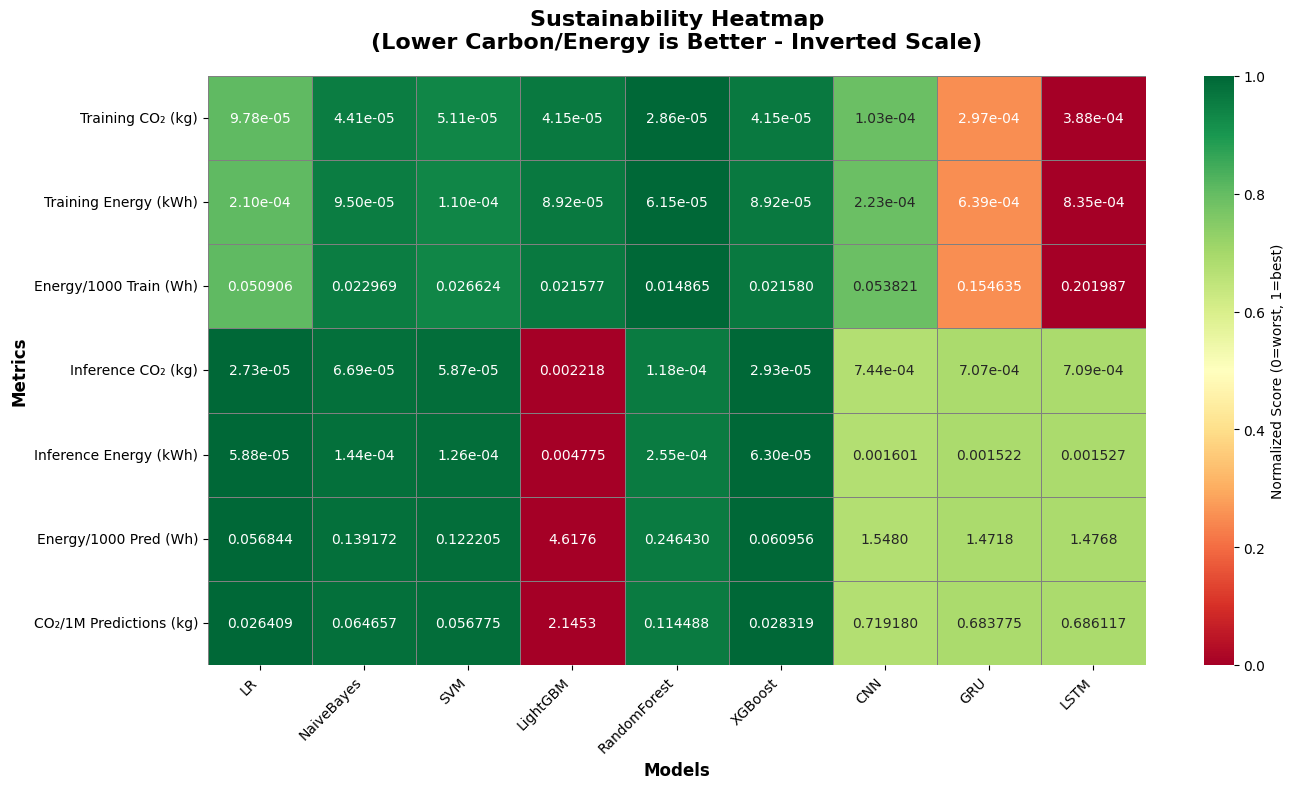

✓ Sustainability Heatmap completed


In [85]:
# ====================================================================================
# HÜCRE 11: COMPREHENSIVE PERFORMANCE HEATMAPS (3 Separate Views)
# ====================================================================================

print("\n" + "=" * 120)
print("GENERATING COMPREHENSIVE PERFORMANCE HEATMAPS")
print("=" * 120)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.close('all')

# ================================================================================
# LOAD RESULTS & PREPARE DATAFRAME
# ================================================================================

# DataFrame oluştur
results_df = pd.DataFrame.from_dict(model_results, orient='index')

# ================================================================================
# DYNAMIC MODEL ORDERING BY CATEGORY (FROM JSON)
# ================================================================================

# Category sırasını tanımla
category_order = ["Classical", "Ensemble", "Deep Learning"]

# Her kategorideki modelleri topla
models_by_category = {cat: [] for cat in category_order}

for model_name in results_df.index:
    category = results_df.loc[model_name, 'Category']
    if category in models_by_category:
        models_by_category[category].append(model_name)

# Sıralı model listesi oluştur
models_order = []
for category in category_order:
    models_order.extend(sorted(models_by_category[category]))  # Alfabetik sırala

print(f"\n📋 Model Order (by Category):")
for category in category_order:
    models_in_cat = [m for m in models_order if results_df.loc[m, 'Category'] == category]
    print(f"   {category}: {', '.join(models_in_cat)}")

# ================================================================================
# NORMALIZATION FUNCTIONS
# ================================================================================

def normalize_higher_is_better(values):
    """Normalize where higher values are better (0=worst, 1=best)"""
    min_val = np.min(values)
    max_val = np.max(values)
    if max_val == min_val:
        return np.ones_like(values)
    return (values - min_val) / (max_val - min_val)

def normalize_lower_is_better(values):
    """Normalize where lower values are better (0=worst, 1=best)"""
    min_val = np.min(values)
    max_val = np.max(values)
    if max_val == min_val:
        return np.ones_like(values)
    return 1 - (values - min_val) / (max_val - min_val)

# ================================================================================
# 1. PERFORMANCE HEATMAP (Classification Metrics)
# ================================================================================

print("\n📊 Creating Performance Heatmap...")

perf_metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1_Score',
    'MCC',
    'ROC_AUC',
    'PR_AUC',
    'Specificity'
]

perf_display = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'MCC',
    'ROC-AUC',
    'PR-AUC',
    'Specificity'
]

# Extract values
perf_matrix = np.zeros((len(perf_metrics), len(models_order)))

for i, metric in enumerate(perf_metrics):
    for j, model in enumerate(models_order):
        if model in results_df.index and metric in results_df.columns:
            perf_matrix[i, j] = results_df.loc[model, metric]
        else:
            perf_matrix[i, j] = 0

# Normalize each metric (higher is better)
perf_normalized = np.zeros_like(perf_matrix)
for i in range(len(perf_metrics)):
    perf_normalized[i, :] = normalize_higher_is_better(perf_matrix[i, :])

# Plot
fig1, ax1 = plt.subplots(figsize=(14, 8))

sns.heatmap(
    perf_normalized,
    annot=perf_matrix,  # Show actual values
    fmt='.4f',
    cmap='RdYlGn',  # Red (bad) → Yellow → Green (good)
    vmin=0,
    vmax=1,
    xticklabels=models_order,
    yticklabels=perf_display,
    cbar_kws={'label': 'Normalized Score (0=worst, 1=best)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax1
)

ax1.set_title('Performance Metrics Heatmap\n(Higher is Better)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Metrics', fontsize=12, fontweight='bold')

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("✓ Performance Heatmap completed")

# ================================================================================
# 2. EFFICIENCY HEATMAP (Speed & Resource Usage)
# ================================================================================

print("\n⚡ Creating Efficiency Heatmap...")

eff_metrics = [
    'Training_Time',
    'Inference_Time_Sec',
    'Latency_ms',
    'Model_Size_MB',
    'RAM_Inference_MB',
    'Parameters_Count'
]

eff_display = [
    'Training Time (s)',
    'Inference Time (s)',
    'Latency (ms)',
    'Model Size (MB)',
    'RAM Inference (MB)',
    'Parameters (count)'
]

# Extract values
eff_matrix = np.zeros((len(eff_metrics), len(models_order)))

for i, metric in enumerate(eff_metrics):
    for j, model in enumerate(models_order):
        if model in results_df.index and metric in results_df.columns:
            value = results_df.loc[model, metric]
            
            # FIX: Handle None, NaN, and string "None"
            if value is None:
                value = 0
            elif isinstance(value, str):
                if value.lower() == 'none' or value.strip() == '':
                    value = 0
                else:
                    try:
                        value = float(value)
                    except (ValueError, TypeError):
                        value = 0
            elif isinstance(value, float) and np.isnan(value):
                value = 0
            
            eff_matrix[i, j] = value
        else:
            eff_matrix[i, j] = 0

# Normalize each metric (lower is better → invert)
eff_normalized = np.zeros_like(eff_matrix)
for i in range(len(eff_metrics)):
    eff_normalized[i, :] = normalize_lower_is_better(eff_matrix[i, :])

# Format values for display
eff_formatted = np.zeros_like(eff_matrix, dtype=object)
for i, metric in enumerate(eff_metrics):
    for j in range(len(models_order)):
        val = eff_matrix[i, j]
        # Format based on metric
        if 'Parameters' in metric:
            eff_formatted[i, j] = f'{val/1e6:.1f}M' if val > 0 else '0'
        elif 'Time' in metric and 'ms' not in metric:
            eff_formatted[i, j] = f'{val:.2f}s'
        elif 'MB' in metric:
            eff_formatted[i, j] = f'{val:.2f}'
        else:
            eff_formatted[i, j] = f'{val:.4f}'

# Plot
fig2, ax2 = plt.subplots(figsize=(14, 7))

sns.heatmap(
    eff_normalized,
    annot=eff_formatted,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    xticklabels=models_order,
    yticklabels=eff_display,
    cbar_kws={'label': 'Normalized Score (0=worst, 1=best)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax2
)

ax2.set_title('Efficiency Heatmap\n(Lower is Better - Inverted Scale)', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Models', fontsize=12, fontweight='bold')
ax2.set_ylabel('Metrics', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("✓ Efficiency Heatmap completed")

# ================================================================================
# 3. SUSTAINABILITY HEATMAP (Carbon & Energy)
# ================================================================================

print("\n🌱 Creating Sustainability Heatmap...")

sust_metrics = [
    'Training_CO2_kg',
    'Training_Energy_kWh',
    'Energy_per_1000_train_Wh',
    'Inference_CO2_kg',
    'Inference_Energy_kWh',
    'Energy_per_1000_pred_Wh',
    'CO2_per_1M_pred_kg'
]

sust_display = [
    'Training CO₂ (kg)',
    'Training Energy (kWh)',
    'Energy/1000 Train (Wh)',
    'Inference CO₂ (kg)',
    'Inference Energy (kWh)',
    'Energy/1000 Pred (Wh)',
    'CO₂/1M Predictions (kg)'
]

# Extract values
sust_matrix = np.zeros((len(sust_metrics), len(models_order)))

for i, metric in enumerate(sust_metrics):
    for j, model in enumerate(models_order):
        if model in results_df.index and metric in results_df.columns:
            value = results_df.loc[model, metric]
            
            # FIX: Handle None, NaN, and string "None"
            if value is None:
                value = 0
            elif isinstance(value, str):
                if value.lower() == 'none' or value.strip() == '':
                    value = 0
                else:
                    try:
                        value = float(value)
                    except (ValueError, TypeError):
                        value = 0
            elif isinstance(value, float) and np.isnan(value):
                value = 0
            
            sust_matrix[i, j] = value
        else:
            sust_matrix[i, j] = 0

# Normalize each metric (lower is better → invert)
sust_normalized = np.zeros_like(sust_matrix)
for i in range(len(sust_metrics)):
    sust_normalized[i, :] = normalize_lower_is_better(sust_matrix[i, :])

# Format values for display
sust_formatted = np.zeros_like(sust_matrix, dtype=object)
for i in range(len(sust_metrics)):
    for j in range(len(models_order)):
        val = sust_matrix[i, j]
        if val < 0.001 and val > 0:
            sust_formatted[i, j] = f'{val:.2e}'
        elif val < 1:
            sust_formatted[i, j] = f'{val:.6f}'
        else:
            sust_formatted[i, j] = f'{val:.4f}'

# Plot
fig3, ax3 = plt.subplots(figsize=(14, 8))

sns.heatmap(
    sust_normalized,
    annot=sust_formatted,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    xticklabels=models_order,
    yticklabels=sust_display,
    cbar_kws={'label': 'Normalized Score (0=worst, 1=best)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax3
)

ax3.set_title('Sustainability Heatmap\n(Lower Carbon/Energy is Better - Inverted Scale)', 
              fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Models', fontsize=12, fontweight='bold')
ax3.set_ylabel('Metrics', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("✓ Sustainability Heatmap completed")

## 12. FEATURE IMPORTANCE (AUTO-REPAIR & VISUALIZATION)


🛠️ SYSTEM CHECK: CountVectorizer ('cv') Status
⚠️ WARNING: 'cv' is missing, corrupted, or has wrong vocabulary size.
   Expected: 57376 | Found: N/A
🔄 Rebuilding and refitting CountVectorizer...
✅ SUCCESS: CountVectorizer repaired.
   Vocabulary Size: 57376
✅ Array sizes consistent: 57376 features

📊 FEATURE IMPORTANCE VISUALIZATION
✅ Saved: 'Spam_Feature_Importance_LR_XGB.png'


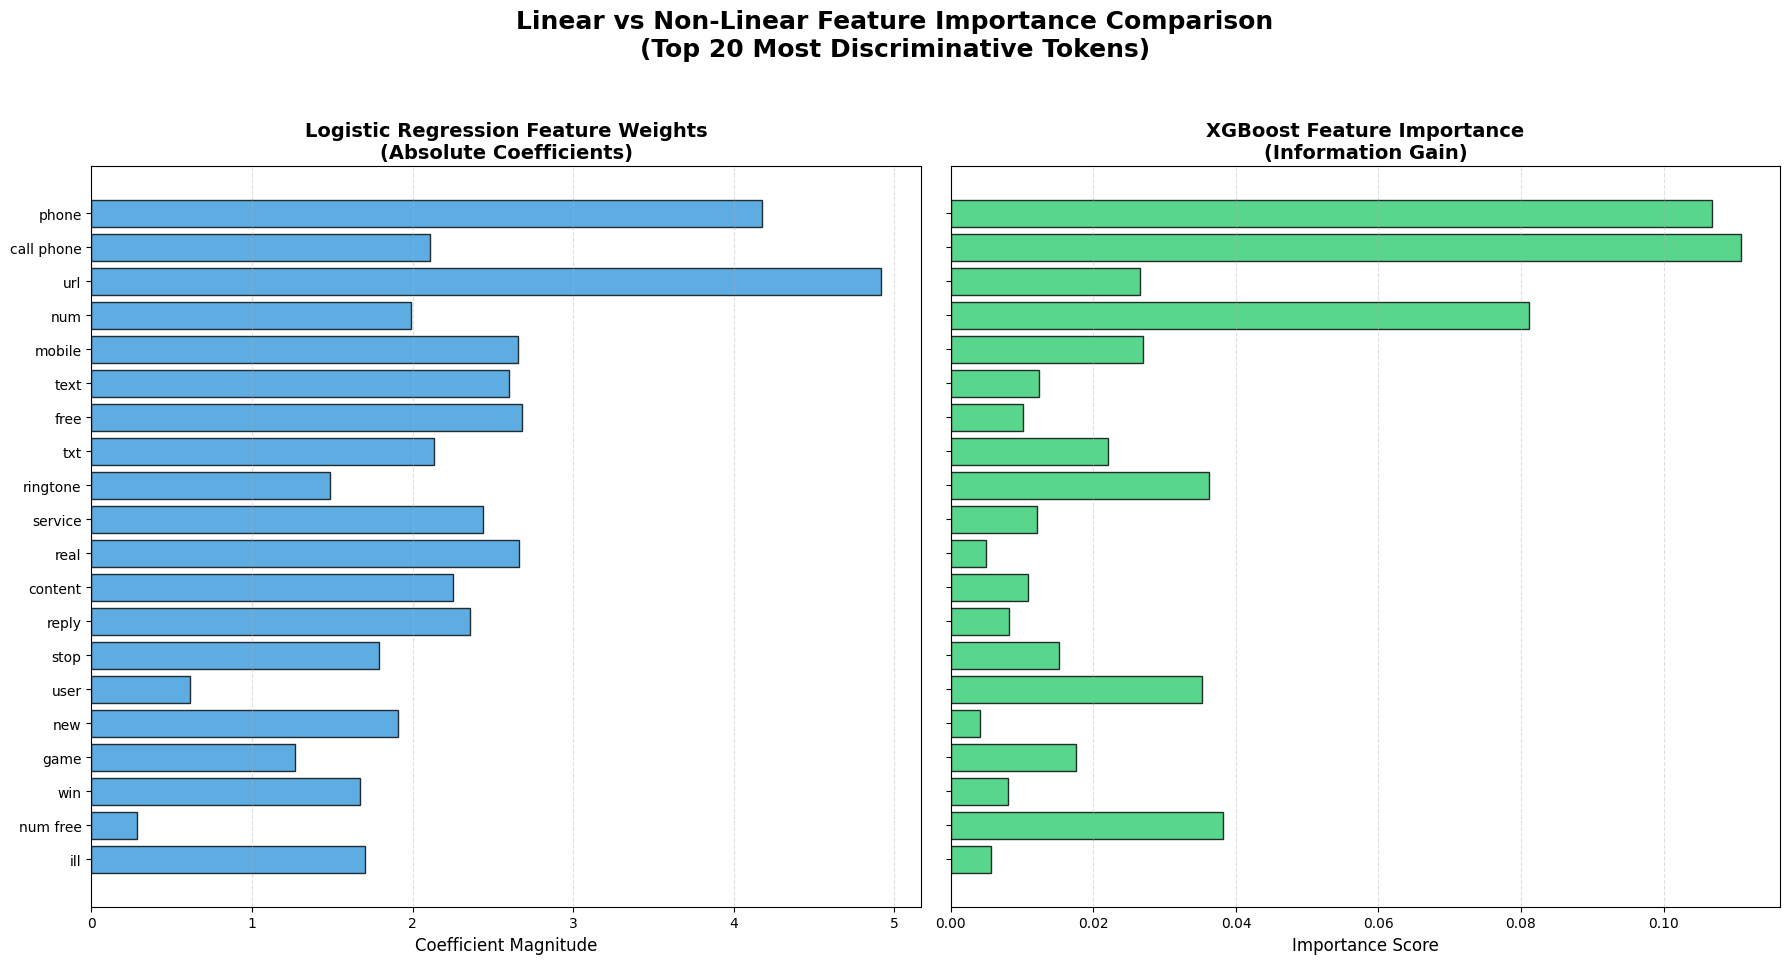


🏆 Top 10 Most Important Words:
   Feature  LogisticRegression  XGBoost
     phone            4.177084 0.106817
call phone            2.106882 0.110805
       url            4.917174 0.026538
       num            1.987624 0.081112
    mobile            2.654856 0.026994
      text            2.602271 0.012406
      free            2.680227 0.010151
       txt            2.134216 0.022042
  ringtone            1.487831 0.036275
   service            2.435210 0.012123


In [79]:
# =============================================================================
# FEATURE IMPORTANCE (AUTO-REPAIR & VISUALIZATION)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

print("\n" + "=" * 100)
print("🛠️ SYSTEM CHECK: CountVectorizer ('cv') Status")
print("=" * 100)

# -----------------------------------------------------------------------------
# 1. AUTO-REPAIR
# -----------------------------------------------------------------------------
# Expected vocabulary size — must match best_lr.coef_ and best_xgb.feature_importances_
EXPECTED_VOCAB_SIZE = best_lr.coef_.shape[1] if 'best_lr' in globals() else 57376

# Repair if: cv missing, lacks get_feature_names_out, OR vocabulary size mismatch
cv_needs_repair = (
    'cv' not in globals()
    or not hasattr(cv, 'get_feature_names_out')
    or len(cv.vocabulary_) != EXPECTED_VOCAB_SIZE
)

if cv_needs_repair:
    print("⚠️ WARNING: 'cv' is missing, corrupted, or has wrong vocabulary size.")
    print(f"   Expected: {EXPECTED_VOCAB_SIZE} | Found: {len(cv.vocabulary_) if 'cv' in globals() and hasattr(cv, 'vocabulary_') else 'N/A'}")
    print("🔄 Rebuilding and refitting CountVectorizer...")

    col_name = "text_classical" if "text_classical" in df.columns else "text"

    try:
        # DATA LEAKAGE PREVENTION (R1 #8):
        # Re-derive train split using same parameters as Cell 23.
        # This is necessary because LSTM/GRU/CNN CV loops overwrite
        # the global train_idx variable with fold indices.
        from sklearn.model_selection import train_test_split as _tts_cv
        _train_idx_cv, _ = _tts_cv(
            df.index, test_size=0.2, random_state=42, stratify=df['target']
        )
        cv = CountVectorizer(min_df=0.0, max_df=1.0, binary=False, ngram_range=(1, 3))
        cv.fit(df.loc[_train_idx_cv, col_name])

        assert len(cv.vocabulary_) == EXPECTED_VOCAB_SIZE, \
            f"Vocabulary size mismatch after repair: {len(cv.vocabulary_)} != {EXPECTED_VOCAB_SIZE}"

        print(f"✅ SUCCESS: CountVectorizer repaired.")
        print(f"   Vocabulary Size: {len(cv.vocabulary_)}")
    except Exception as e:
        print(f"❌ ERROR: Repair failed.\nError: {e}")
        raise
else:
    print(f"✅ STATUS: 'cv' object is intact and ready.")
    print(f"   Vocabulary Size: {len(cv.vocabulary_)}")

# -----------------------------------------------------------------------------
# 2. PRE-FLIGHT CHECK — verify all arrays match before DataFrame creation
# -----------------------------------------------------------------------------
feature_names = cv.get_feature_names_out()
lr_imp        = np.abs(best_lr.coef_[0])  if 'best_lr'  in globals() else None
xgb_imp       = best_xgb.feature_importances_ if 'best_xgb' in globals() else None

if lr_imp is not None and xgb_imp is not None:
    assert len(feature_names) == len(lr_imp),  f"Size mismatch: feature_names={len(feature_names)}, lr_imp={len(lr_imp)}"
    assert len(feature_names) == len(xgb_imp), f"Size mismatch: feature_names={len(feature_names)}, xgb_imp={len(xgb_imp)}"
    print(f"✅ Array sizes consistent: {len(feature_names)} features")

# -----------------------------------------------------------------------------
# 3. FEATURE IMPORTANCE ANALYSIS (LR vs XGBoost)
# -----------------------------------------------------------------------------
print("\n" + "=" * 100)
print("📊 FEATURE IMPORTANCE VISUALIZATION")
print("=" * 100)

if 'best_lr' in globals() and 'best_xgb' in globals():

    df_imp = pd.DataFrame({
        'Feature':            feature_names,
        'LogisticRegression': lr_imp,
        'XGBoost':            xgb_imp
    })

    # Normalize to [0, 1]
    df_imp['LR_Norm']  = df_imp['LogisticRegression'] / df_imp['LogisticRegression'].max()
    df_imp['XGB_Norm'] = df_imp['XGBoost'] / df_imp['XGBoost'].max()

    # Sort by mean importance score and take top 20
    df_imp['Mean_Score'] = (df_imp['LR_Norm'] + df_imp['XGB_Norm']) / 2
    df_plot = df_imp.sort_values('Mean_Score', ascending=False).head(20)
    df_plot = df_plot.sort_values('Mean_Score', ascending=True)  # Reverse for horizontal bar

    # Visualization
    plt.close('all')
    fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

    # Plot 1: Logistic Regression
    axes[0].barh(df_plot['Feature'], df_plot['LogisticRegression'],
                 color='#3498db', alpha=0.8, edgecolor='black')
    axes[0].set_title('Logistic Regression Feature Weights\n(Absolute Coefficients)',
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Coefficient Magnitude', fontsize=12)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    # Plot 2: XGBoost
    axes[1].barh(df_plot['Feature'], df_plot['XGBoost'],
                 color='#2ecc71', alpha=0.8, edgecolor='black')
    axes[1].set_title('XGBoost Feature Importance\n(Information Gain)',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Importance Score', fontsize=12)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    plt.suptitle(
        'Linear vs Non-Linear Feature Importance Comparison\n(Top 20 Most Discriminative Tokens)',
        fontsize=18, fontweight='bold', y=0.96
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    try:
        plt.savefig('Spam_Feature_Importance_LR_XGB.png', dpi=300, bbox_inches='tight')
        print("✅ Saved: 'Spam_Feature_Importance_LR_XGB.png'")
    except:
        pass

    plt.show()

    print("\n🏆 Top 10 Most Important Words:")
    print(df_plot.sort_values('Mean_Score', ascending=False)[
        ['Feature', 'LogisticRegression', 'XGBoost']
    ].head(10).to_string(index=False))

else:
    print("⚠️ ERROR: 'best_lr' or 'best_xgb' not found in memory. Please train models first.")